In [2]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.interference_models.pca import loo_pca, malinowski_ind, pca
import pandas as pd 
from vebir.utils.distribute import distribute_veb

import matplotlib.pyplot as plt
import multiprocessing as mp
from vebir.absorbance_estimators.veb import VEB
from scipy.linalg import svd
from vebir.utils.bootstrap import pca_bootstrap, compute_lod

In [3]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "airmon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "airmon"

In [4]:
with open(CORRECTIONS_DIR / "SO4.pkl", "rb") as f:
    SO4 =pickle.load(f)


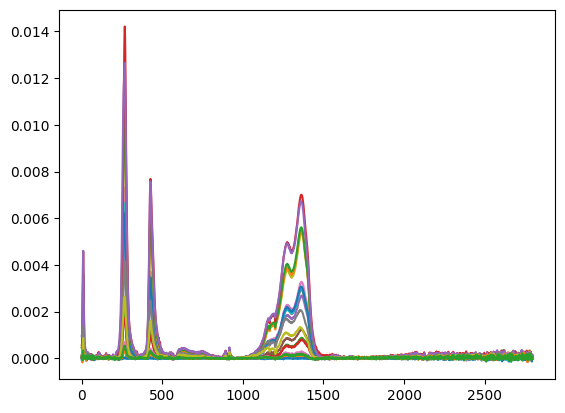

In [5]:
for i in SO4:
    if i["sample_id"] in [
        '20250604_ammoniumsulfate_calibration_7_A',
        '20250604_ammoniumsulfate_calibration_9_A',
        '20250604_ammoniumsulfate_calibration_10_B',
        '20250604_ammoniumsulfate_calibration_8_B'
    ]:
        continue
    plt.plot(i["absorbance"])

In [9]:
SO4[0]["boot_z"]

array([[1.67375903, 1.67000313, 1.66932938, ..., 1.47131725, 1.47205282,
        1.47272387],
       [1.6737434 , 1.66996476, 1.66927558, ..., 1.47130617, 1.47204884,
        1.47275994],
       [1.67371801, 1.66996244, 1.66931393, ..., 1.47129173, 1.47208418,
        1.47274653],
       ...,
       [1.67380357, 1.6700413 , 1.66933847, ..., 1.47138357, 1.47204884,
        1.47273031],
       [1.67376587, 1.67000005, 1.66932507, ..., 1.47132897, 1.47199202,
        1.47273164],
       [1.67376953, 1.66996244, 1.66921916, ..., 1.47131725, 1.47208474,
        1.47273031]], shape=(100, 2799))

In [35]:
np.corrcoef(np.array(ZSO4_crystalB.iloc[0]),NO3[j]["stdev"])

NameError: name 'ZSO4_crystalB' is not defined

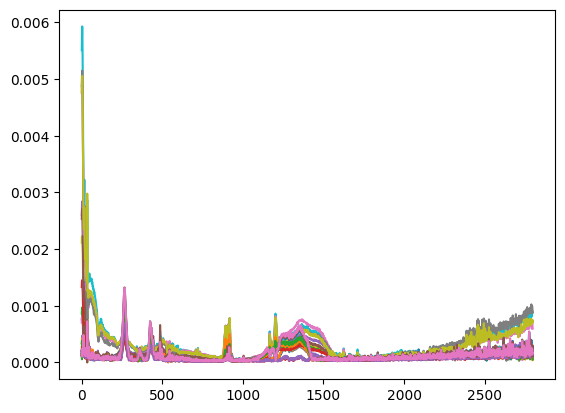

In [60]:
for j in range(len(SO4)):
#plt.plot(SO4[j]["absorbance"])
    plt.plot(SO4[j]["xi"]*SO4[j]["stdev"])

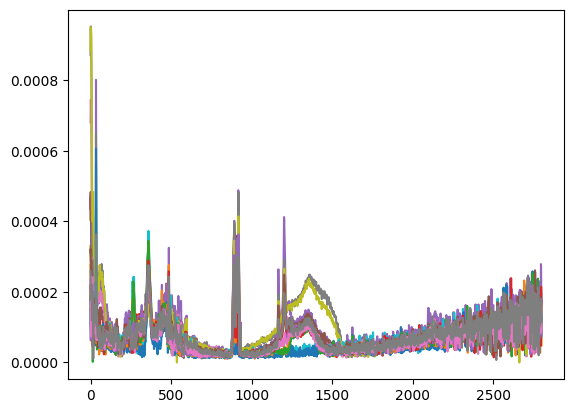

In [61]:
for j in range(len(NO3)):
#plt.plot(SO4[j]["absorbance"])
    plt.plot(NO3[j]["xi"]*NO3[j]["stdev"])

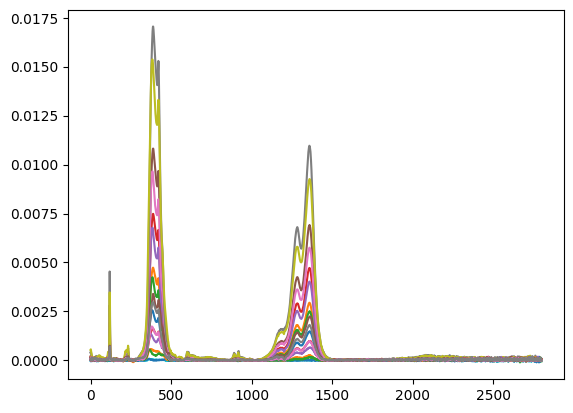

In [39]:
with open(CORRECTIONS_DIR / "NO3.pkl", "rb") as f:
    NO3 =pickle.load(f)
    
for i in NO3:
    if i["sample_id"] in [
        '20250604_ammoniumsulfate_calibration_7_A',
        '20250604_ammoniumsulfate_calibration_9_A',
        '20250604_ammoniumsulfate_calibration_10_B',
        '20250604_ammoniumsulfate_calibration_8_B'
    ]:
        continue
    plt.plot(i["absorbance"])

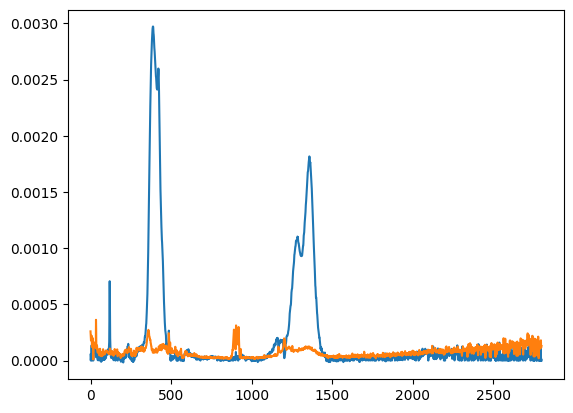

In [59]:
j = 17
plt.plot(NO3[j]["absorbance"])
plt.plot(NO3[j]["xi"]*NO3[j]["stdev"])

In [25]:


cleaned_spectra_dict_path = PREPROC_DIR / "cleaned_spectra_dict.pkl"

with open(cleaned_spectra_dict_path, "rb") as f:
    cleaned_spectra_dict = pickle.load(f)
    
loaded_spectra_dict_path = PREPROC_DIR / "loaded_spectra_dict.pkl"
with open(loaded_spectra_dict_path, "rb") as f:
    loaded_spectra_dict = pickle.load(f)

YSO4 = loaded_spectra_dict["ammonium_sulphate_calibration"].copy()
YNO3 = loaded_spectra_dict["ammonium_nitrate_calibration"].copy()
YJAP = loaded_spectra_dict["japan"].copy()

ZSO4 = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()
ZNO3 = cleaned_spectra_dict["ammonium_nitrate_calibration"].copy()
ZJAP = cleaned_spectra_dict["japan"].copy()

Zamb = cleaned_spectra_dict["ambient_measurements"].copy()
Yamb = loaded_spectra_dict["ambient_measurements"].copy()

wn = YSO4.columns.astype(float)

In [4]:
# for i in range(Zamb.shape[0]):
#     plt.plot(wn, Zamb.iloc[i], color="gray", alpha=0.5)

In [26]:
ZSO4_crystalA = ZSO4[ZSO4.index.astype(str).str.endswith("A")].copy()

In [3]:
YSO4_crystalA = YSO4[YSO4.index.astype(str).str.endswith("A")].copy()
ZSO4_crystalA = ZSO4[ZSO4.index.astype(str).str.endswith("A")].copy()

contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

ZSO4_crystalA.drop(index=contaminated_names, inplace=True)

YSO4_crystalB = YSO4[YSO4.index.astype(str).str.endswith("B")].copy()
ZSO4_crystalB = ZSO4[ZSO4.index.astype(str).str.endswith("B")].copy()

contaminated_names = ["20250603_ammoniumsulfate_calibration_4_B",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",]

ZSO4_crystalB.drop(index=contaminated_names, inplace=True)

YNO3_crystalA = YNO3[YNO3.index.astype(str).str.endswith("A")].copy()
ZNO3_crystalA = ZNO3[ZNO3.index.astype(str).str.endswith("A")].copy()

contaminated_names = ["ammonium_nitrate_calibration_5_A","ammonium_nitrate_calibration_7_A"]

ZNO3_crystalA.drop(index=contaminated_names, inplace=True)

YNO3_crystalB = YNO3[YNO3.index.astype(str).str.endswith("B")].copy()
ZNO3_crystalB = ZNO3[ZNO3.index.astype(str).str.endswith("B")].copy()

contaminated_names = ["ammonium_nitrate_calibration_6_B"]

ZNO3_crystalB.drop(index=contaminated_names, inplace=True)

ZJAP_crystalA = ZJAP[ZJAP.index.astype(str).str.endswith("A")].copy()
ZJAP_crystalB = ZJAP[ZJAP.index.astype(str).str.endswith("B")].copy()

YJAP_crystalA = YJAP[YJAP.index.astype(str).str.endswith("A")].copy()
YJAP_crystalB = YJAP[YJAP.index.astype(str).str.endswith("B")].copy() 

Zamb_crystalA = Zamb[Zamb.index.astype(str).str.endswith("A")].copy()
Zamb_crystalB = Zamb[Zamb.index.astype(str).str.endswith("B")].copy()

Yamb_crystalA = Yamb[Yamb.index.astype(str).str.endswith("A")].copy()
Yamb_crystalB = Yamb[Yamb.index.astype(str).str.endswith("B")].copy()


In [8]:
ZA = pd.concat([ZSO4_crystalA,ZNO3_crystalA, ZJAP_crystalA, Zamb_crystalA], axis=0)
ZA = np.array(ZA)

ZB = pd.concat([ZSO4_crystalB,ZNO3_crystalB, ZJAP_crystalB, Zamb_crystalB], axis=0)
ZB = np.array(ZB)

Z = np.concatenate([ZA,ZB], axis=0)

In [9]:
chat_min, chat_ose, Err = loo_pca(Z)
mu, _, _, W = pca(Z)
W = W[:,:chat_ose]

In [10]:
Y = YSO4_crystalA

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    

100%|██████████| 14/14 [03:15<00:00, 13.95s/it]


In [11]:
j = 8
y = np.array(Y.iloc[j])
tau = res_NO3[j]["tau"]
sigma = res_NO3[j]["sigma_hat"]
z = y -  res_NO3[j]["absorbance"]

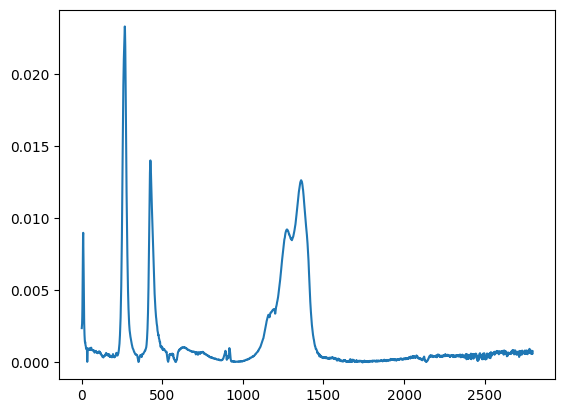

In [12]:
plt.plot(y-z)

In [13]:
boot_x, boot_z = pca_bootstrap(y, Z, tau , sigma , c= W.shape[1] , B=100, loss="PB", verbose=True)
psi, stdev = compute_lod(boot_z, z)

100%|██████████| 100/100 [10:18<00:00,  6.18s/it]


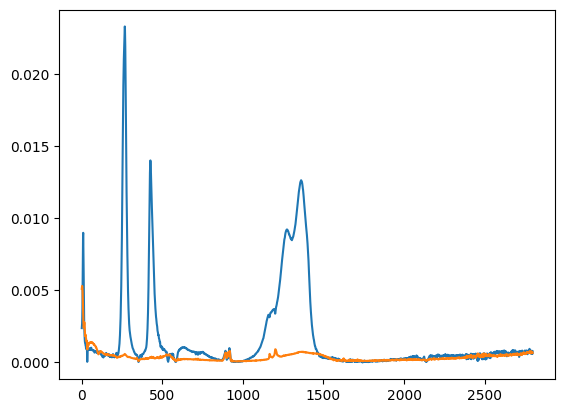

In [15]:
plt.plot(y-z)
plt.plot(psi*stdev)

In [17]:
a = y - z

In [19]:
lod = psi*stdev 

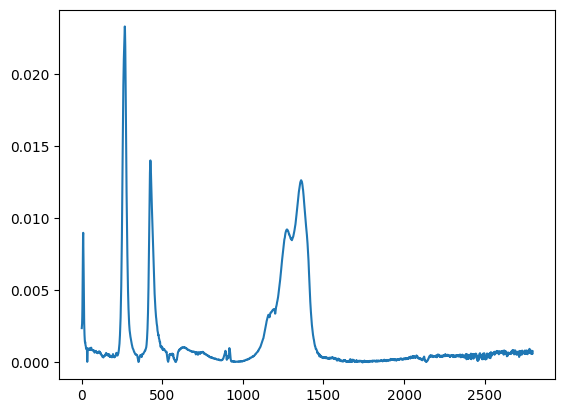

In [22]:
plt.plot(a)

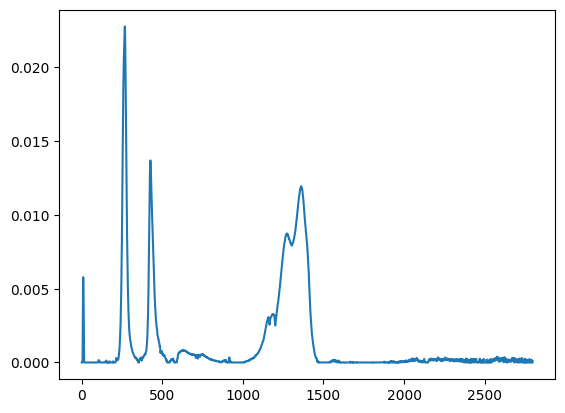

In [23]:
atrunc = np.where(a-lod<0, 0, a-lod)
plt.plot(atrunc)


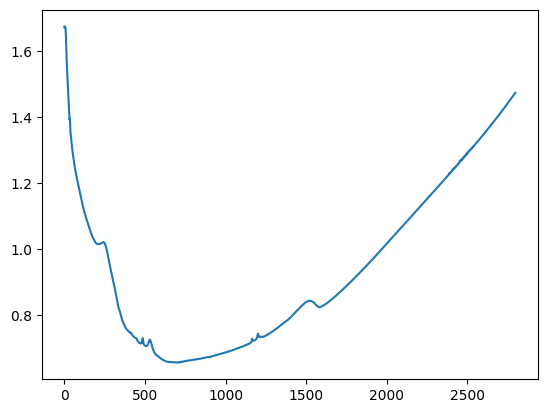

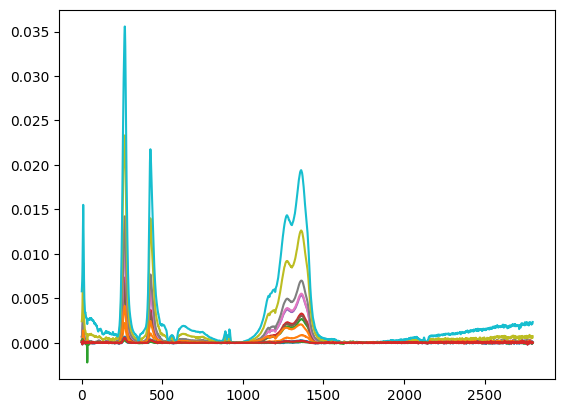

In [36]:
for i in res_NO3:
    plt.plot(i["absorbance"])

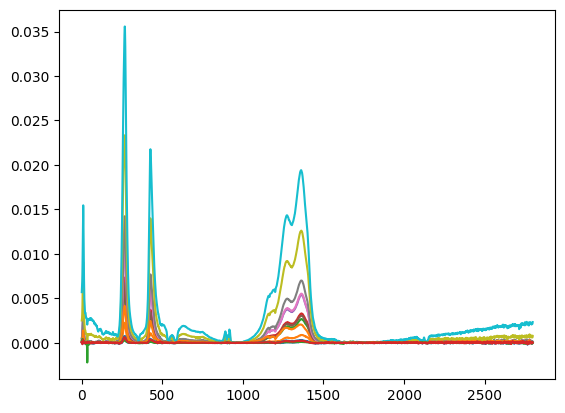

In [31]:
for i in res_NO3:
    plt.plot(i["absorbance"])

In [17]:
chat_cv = loo_pca(ZA,max_ncomp=ZA.shape[0]-1)[1]
muA, _, _, W = pca(ZA)
WA = W[:, :chat_cv]

chat_cv = loo_pca(ZB,max_ncomp=ZB.shape[0]-1)[1]
muB, _, _, W = pca(ZB)
WB = W[:, :chat_cv]

results_all_wn = {}

In [ ]:
Y = YNO3_crystalA

distribute_args = [(np.array(Y.iloc[i]), muA, WA, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_all_wn["NO3_A"] = res_NO3

Y = YNO3_crystalB

distribute_args = [(np.array(Y.iloc[i]), muB, WB, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_all_wn["NO3_B"] = res_NO3

100%|██████████| 9/9 [00:03<00:00,  2.58it/s]


In [25]:
Y = YSO4_crystalA

distribute_args = [(np.array(Y.iloc[i]), muA, WA, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_all_wn["SO4_A"] = res_SO4

Y = YSO4_crystalB

distribute_args = [(np.array(Y.iloc[i]), muB, WB, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_all_wn["SO4_B"] = res_SO4

100%|██████████| 13/13 [00:29<00:00,  2.28s/it]


In [31]:
with open("../data/temp/results_all_wn_separated.pkl", "wb") as f:   
     pickle.dump(results_all_wn, f)

In [34]:
idx = np.where(wn <= 4000)[0]
ZA = ZA[:, idx]
ZB = ZB[:, idx]
YSO4_crystalA = YSO4_crystalA.iloc[:, idx]
YSO4_crystalB = YSO4_crystalB.iloc[:, idx]
YNO3_crystalA = YNO3_crystalA.iloc[:, idx]
YNO3_crystalB = YNO3_crystalB.iloc[:, idx]


chat_cv = loo_pca(ZA,max_ncomp=ZA.shape[0]-1)[1]
muA, _, _, W = pca(ZA)
WA = W[:, :chat_cv]

chat_cv = loo_pca(ZB,max_ncomp=ZB.shape[0]-1)[1]
muB, _, _, W = pca(ZB)
WB = W[:, :chat_cv]

results_reduced_wn = {}



In [35]:
Y = YSO4_crystalA

distribute_args = [(np.array(Y.iloc[i]), muA, WA, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_reduced_wn["SO4_A"] = res_SO4

Y = YSO4_crystalB

distribute_args = [(np.array(Y.iloc[i]), muB, WB, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_reduced_wn["SO4_B"] = res_SO4

100%|██████████| 13/13 [00:06<00:00,  1.94it/s]


In [40]:
Y = YNO3_crystalA

distribute_args = [(np.array(Y.iloc[i]), muA, WA, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_reduced_wn["NO3_A"] = res_NO3

Y = YNO3_crystalB

distribute_args = [(np.array(Y.iloc[i]), muB, WB, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_reduced_wn["NO3_B"] = res_NO3

100%|██████████| 9/9 [00:06<00:00,  1.47it/s]


In [43]:
with open("../data/temp/results_reduced_wn_separated.pkl", "wb") as f:   
     pickle.dump(results_reduced_wn, f)

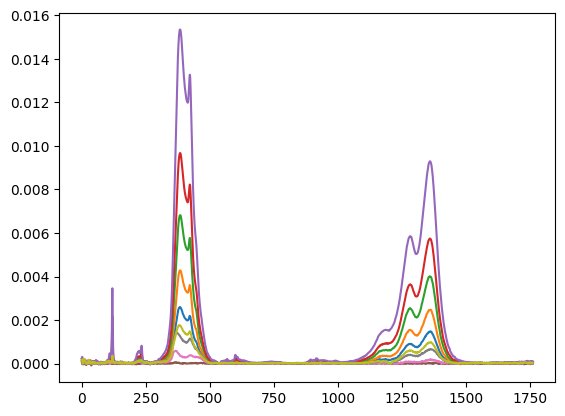

In [42]:
for i in results_reduced_wn["NO3_B"]:
    if i["sample_id"] in [
        '20250604_ammoniumsulfate_calibration_7_A',
        '20250604_ammoniumsulfate_calibration_9_A',
        '20250604_ammoniumsulfate_calibration_10_B',
        '20250604_ammoniumsulfate_calibration_8_B'
    ]:
        continue
    plt.plot(i["absorbance"])

In [44]:
def help_fun(Y,Z):
    Z = np.array(Z)
    c1hat_cv = loo_pca(Z,max_ncomp=Z.shape[0]-1)[1]
    mu, _, _, W = pca(Z)
    W = W[:, :c1hat_cv]
    

    distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
    with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )
                    
                    
    E = np.array([i["absorbance"] for i in results])   
    
    c2hat_cv = loo_pca(E,max_ncomp=E.shape[0]-1)[1]
    mu1, _, _, W1 = pca(E)
    W1 = W1[:, :c2hat_cv]
    
            
    mu = mu1 + mu
    W = np.hstack((W, W1))        
                    
    return results, mu, W, c1hat_cv, c2hat_cv

In [79]:
Z = pd.concat([ZSO4_crystalB,ZNO3_crystalB,ZNO3_crystalA,ZJAP_crystalA], axis=0)
Z = np.array(Z)

results, mu, W, c1hat_cv, c2hat_cv = help_fun(ZSO4_crystalA,Z)

100%|██████████| 13/13 [00:19<00:00,  1.52s/it]


In [80]:
c1hat_cv, c2hat_cv

(np.int64(52), np.int64(2))

In [81]:
Y = YSO4_crystalA

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    

100%|██████████| 14/14 [00:26<00:00,  1.86s/it]


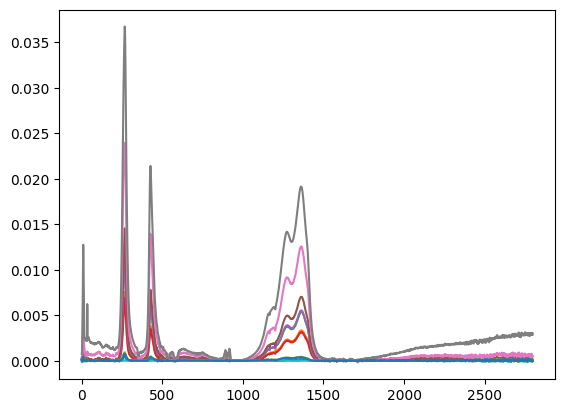

In [83]:
for i in res_SO4:
    if i["sample_id"] in [
        '20250603_ammoniumsulfate_calibration_3_A',
       '20250603_ammoniumsulfate_calibration_5_A',
       '20250605_ammoniumsulfate_calibration5k_3_A',
       '20250605_ammoniumsulfate_calibration5k_smallertime_5_A'
    ]:
        continue
    plt.plot(i["absorbance"])

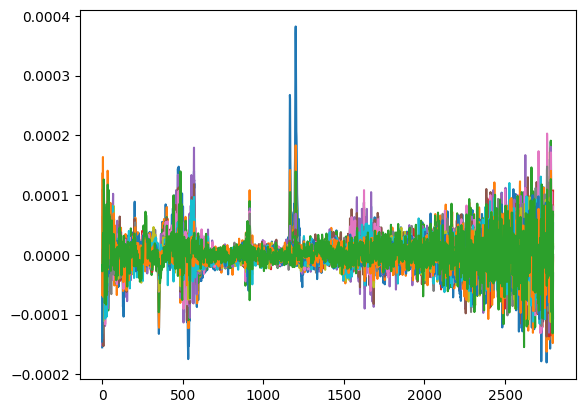

In [84]:
for i in results:
    plt.plot(i["absorbance"])

In [ ]:
aa

In [6]:
Z = pd.concat([ZSO4_crystalA,ZSO4_crystalB,ZNO3_crystalA, ZNO3_crystalB, ZJAP_crystalA,  ZJAP_crystalB, Zamb_crystalA, Zamb_crystalB], axis=0)
Z = np.array(Z)

In [ ]:
chat_cv = loo_pca(Z,max_ncomp=Z.shape[0]-1)[1]
mu, _, _, W = pca(Z)
W = W[:, :chat_cv]

In [19]:
results_all_wn = {}

In [ ]:
Y = YNO3

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_all_wn["NO3"] = res_NO3

100%|██████████| 18/18 [03:54<00:00, 13.04s/it]


In [24]:
Y = YSO4

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    

results_all_wn["SO4"] = res_SO4               

100%|██████████| 27/27 [05:59<00:00, 13.30s/it]  


In [ ]:
# with open("../data/temp/results_all_wn.pkl", "wb") as f:   
#     pickle.dump(results_all_wn, f)

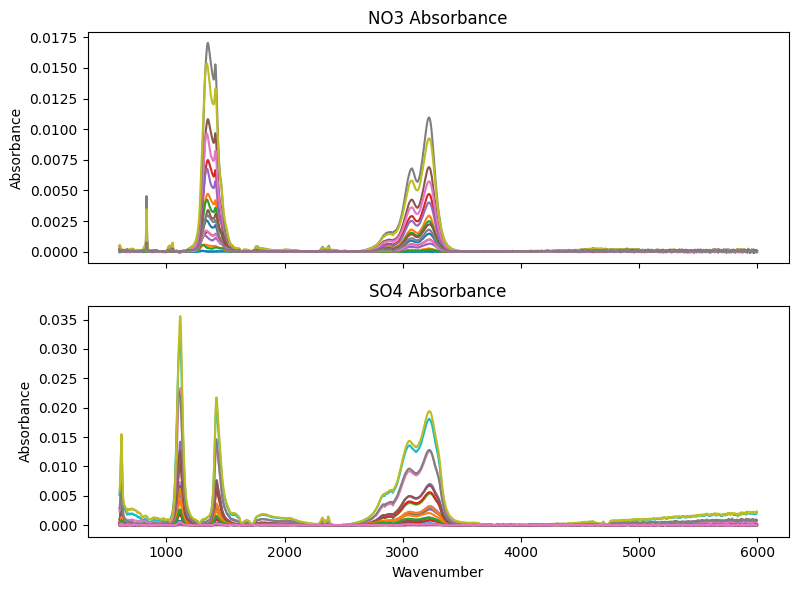

In [7]:
with open("../data/temp/results_all_wn.pkl", "rb") as f:   
    results_all_wn = pickle.load(f)
    
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# --- NO3 subplot ---
for i in results_all_wn["NO3"]:
    ax1.plot(wn, i["absorbance"])
ax1.set_title("NO3 Absorbance")
ax1.set_ylabel("Absorbance")

# --- SO4 subplot ---
for i in results_all_wn["SO4"]:
    ax2.plot(wn, i["absorbance"])
ax2.set_title("SO4 Absorbance")
ax2.set_xlabel("Wavenumber")
ax2.set_ylabel("Absorbance")

plt.tight_layout()
plt.show()

In [9]:
idx = np.where(wn <= 4000)[0]

In [ ]:


Z = Z[:,idx]
chat_cv = loo_pca(Z,max_ncomp=Z.shape[0]-1)[1]
mu, _, _, W = pca(Z)
W = W[:, :chat_cv]

results_reduced_wn = {}

NameError: name 'Z' is not defined

In [8]:
Y = YNO3.iloc[:,idx]

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_NO3 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_reduced_wn["NO3"] = res_NO3

100%|██████████| 18/18 [01:53<00:00,  6.30s/it]


In [11]:
with open("../data/temp/results_reduced_wn.pkl", "wb") as f:   
    pickle.dump(results_reduced_wn, f)

In [10]:
Y = YSO4.iloc[:,idx]

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
results_reduced_wn["SO4"] = res_SO4

100%|██████████| 27/27 [02:56<00:00,  6.55s/it]  


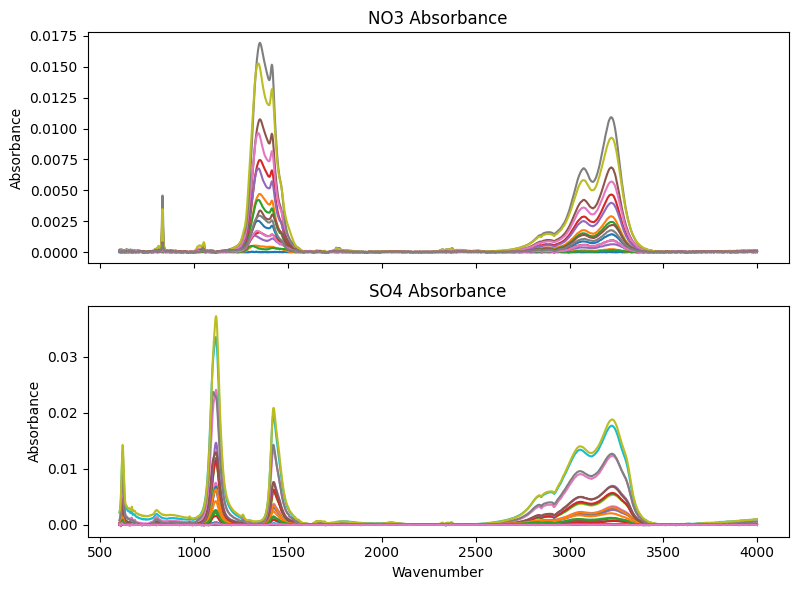

In [10]:
with open("../data/temp/results_reduced_wn.pkl", "rb") as f:   
    results_reduced_wn = pickle.load(f)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# --- NO3 subplot ---
for i in results_reduced_wn["NO3"]:
    ax1.plot(wn[idx], i["absorbance"])
ax1.set_title("NO3 Absorbance")
ax1.set_ylabel("Absorbance")

# --- SO4 subplot ---
for i in results_reduced_wn["SO4"]:
    ax2.plot(wn[idx], i["absorbance"])
ax2.set_title("SO4 Absorbance")
ax2.set_xlabel("Wavenumber")
ax2.set_ylabel("Absorbance")

plt.tight_layout()
plt.show()

In [79]:
def help_fun(Y,Z):
    Z = np.array(Z)
    c1hat_cv = loo_pca(Z,max_ncomp=Z.shape[0]-1)[1]
    mu, _, _, W = pca(Z)
    W = W[:, :c1hat_cv]
    

    distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
    with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )
                    
                    
    E = np.array([i["absorbance"] for i in results])   
    
    c2hat_cv = loo_pca(E,max_ncomp=E.shape[0]-1)[1]
    mu1, _, _, W1 = pca(E)
    W1 = W1[:, :c2hat_cv]
    
            
    mu = mu1 + mu
    W = np.hstack((W, W1))        
                    
    return results, mu, W, c1hat_cv, c2hat_cv

In [94]:
ZT = ZSO4_crystalA
ZA = pd.concat([ZNO3_crystalA, ZJAP_crystalA, Zamb_crystalA,ZSO4_crystalB , ZNO3_crystalB, ZJAP_crystalB, Zamb_crystalB], axis=0)

In [95]:
res, mu, W, c1hat_cv, c2hat_cv = help_fun(ZT,ZA)

100%|██████████| 13/13 [03:17<00:00, 15.19s/it]


In [96]:
print(f"c1hat_cv: {c1hat_cv}, c2hat_cv: {c2hat_cv}")

c1hat_cv: 205, c2hat_cv: 1


In [115]:
Z = pd.concat([ZSO4_crystalA,ZNO3_crystalA, ZJAP_crystalA, Zamb_crystalA,ZSO4_crystalB , ZNO3_crystalB, ZJAP_crystalB, Zamb_crystalB], axis=0)
idx = np.where(wn <= 4000)[0]

In [116]:
Z = np.array(Z)[:,idx]
c1hat_cv = loo_pca(Z,max_ncomp=Z.shape[0]-1)[1]
mu, _, _, W = pca(Z)
W = W[:, :c1hat_cv]

100%|██████████| 18/18 [01:54<00:00,  6.36s/it]


In [122]:
Y = YSO4.iloc[:,idx]

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    res_SO4 = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    

100%|██████████| 27/27 [02:47<00:00,  6.19s/it]  


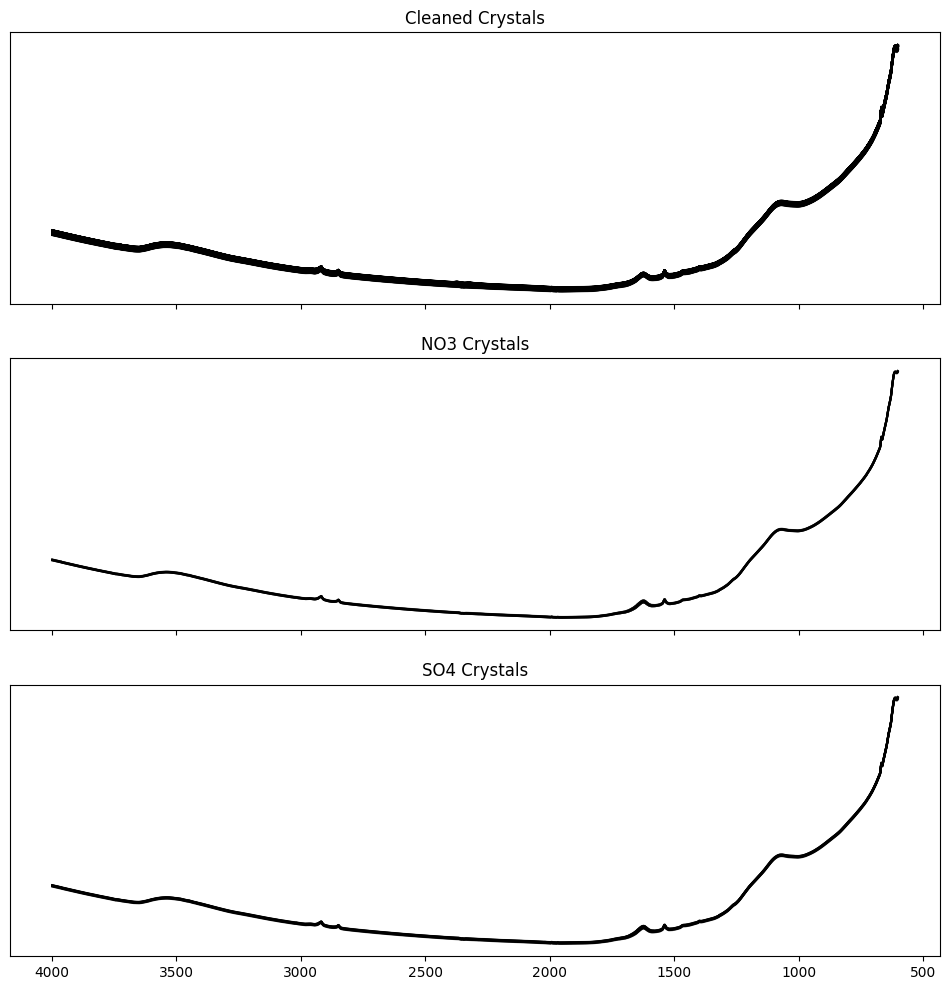

In [123]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

idx = np.where(wn <= 4000)[0]

for i in range(Z.shape[0]):
    axes[0].plot(wn[idx], Z[i,idx], c='k', alpha=0.3)
axes[0].set_title("Cleaned Crystals")
axes[0].set_yticks([])         
axes[0].set_ylabel('')        

for i in range(ZNO3.shape[0]):
    axes[1].plot(wn[idx], ZNO3.iloc[i,idx], c='k', alpha=0.3)
axes[1].set_title("NO3 Crystals")
axes[1].set_yticks([])         
axes[1].set_ylabel('')


for i in range(ZSO4.shape[0]):
    axes[2].plot(wn[idx], ZSO4.iloc[i,idx], c='k', alpha=0.3)
axes[2].set_title("SO4 Crystals")
axes[2].set_yticks([])         
axes[2].set_ylabel('')
axes[2].invert_xaxis()  

plt.savefig('../data/temp/crystals.png', dpi=300, bbox_inches='tight')
plt.show()

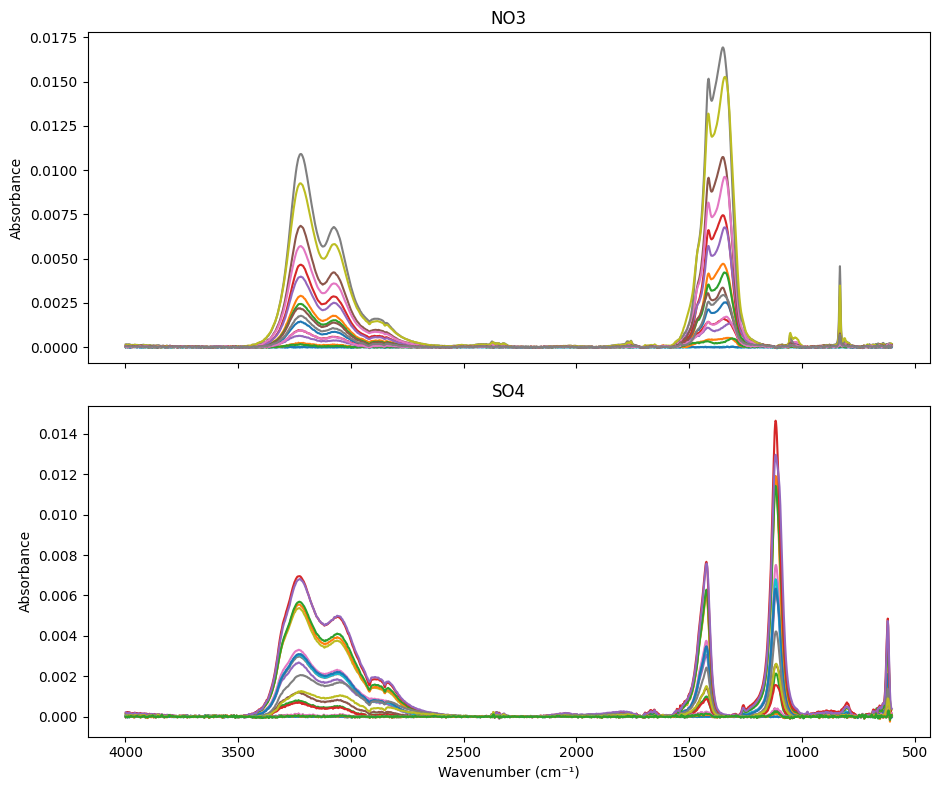

In [126]:

# Create a figure with 3 subplots in one column
fig, axes = plt.subplots(2, 1, figsize=(9.5, 8), sharex=True)  # sharex ensures same x-axis


for i in res_NO3:
    axes[0].plot(wn[idx], i["absorbance"][idx], alpha=1.0)
axes[0].set_ylabel("Absorbance")
axes[0].set_title("NO3")  # optional title

for i in res_SO4:
    if i["sample_id"] in [
        '20250604_ammoniumsulfate_calibration_7_A',
        '20250604_ammoniumsulfate_calibration_9_A',
        '20250604_ammoniumsulfate_calibration_10_B',
        '20250604_ammoniumsulfate_calibration_8_B'
    ]:
        continue
    axes[1].plot(wn[idx], i["absorbance"][idx], alpha=1.0)
axes[1].set_xlabel("Wavenumber (cm⁻¹)")
axes[1].set_ylabel("Absorbance")
axes[1].set_title("SO4")  # optional title
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig('../data/temp/combined_ABS.png', dpi=300, bbox_inches='tight')

# Show
plt.show()


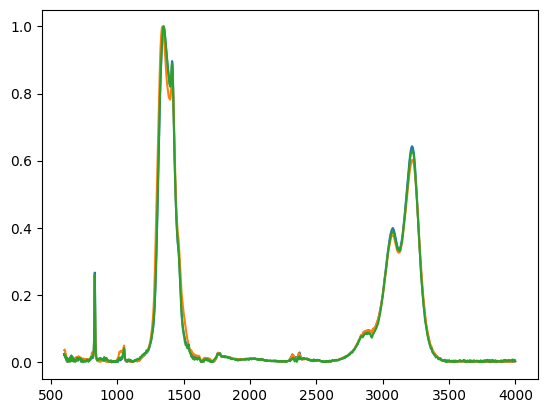

In [97]:
plt.plot(wn[idx], res_NO3[7]["absorbance"][idx]/np.max(res_NO3[7]["absorbance"][idx]), alpha=1.0)
plt.plot(wn[idx], res_NO3[8]["absorbance"][idx]/np.max(res_NO3[8]["absorbance"][idx]), alpha=1.0)
plt.plot(wn[idx], res_NO3[3]["absorbance"][idx]/np.max(res_NO3[3]["absorbance"][idx]), alpha=1.0)

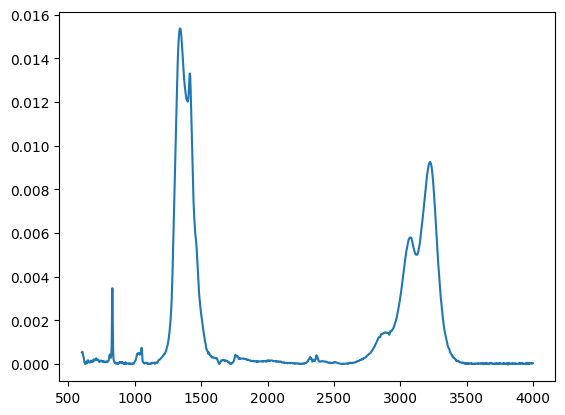

In [32]:
A = np.array([i["absorbance"] for i in results])

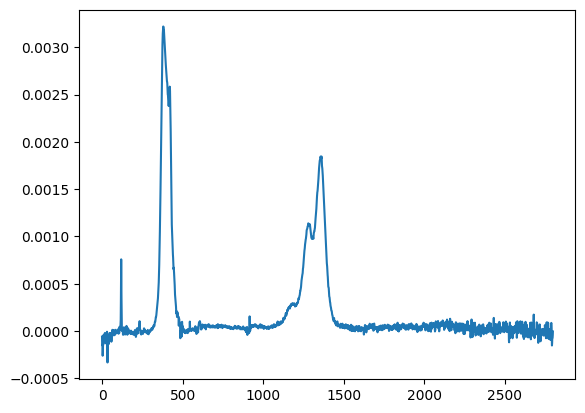

In [33]:
plt.plot(np.mean(A, axis=0))

100%|██████████| 14/14 [02:48<00:00, 12.07s/it]


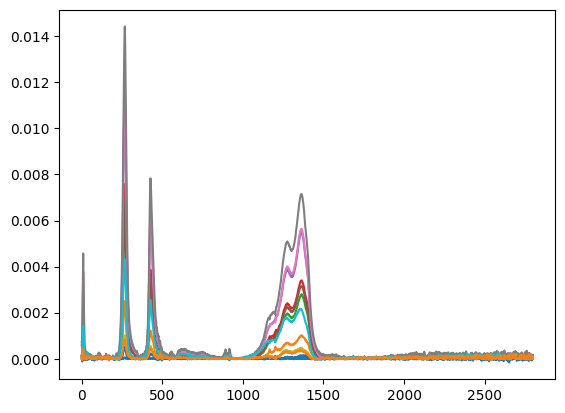

In [97]:
Y = YSO4_crystalA.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 14/14 [00:03<00:00,  4.48it/s]


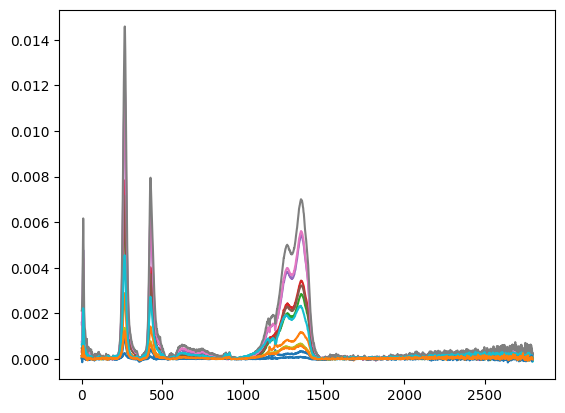

In [93]:
Y = YSO4_crystalA.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

In [28]:
ZA = pd.concat([ZSO4_crystalA, ZNO3_crystalA, ZJAP_crystalA, Zamb_crystalA ], axis=0)
ZB = pd.concat([ZSO4_crystalB, ZNO3_crystalB, ZJAP_crystalB, Zamb_crystalB ], axis=0)

In [66]:
help_fun

NameError: name 'help_fun' is not defined

In [20]:
Z = np.array(ZA)
chat_cv = loo_pca(Z,max_ncomp=Z.shape[1])[1]
mu, _, _, W = pca(Z)
W = W[:, :chat_cv]
print(chat_cv)

31


100%|██████████| 14/14 [00:04<00:00,  3.05it/s]


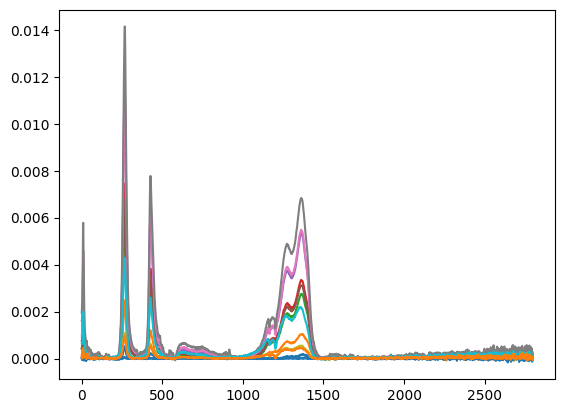

100%|██████████| 9/9 [00:03<00:00,  2.80it/s]


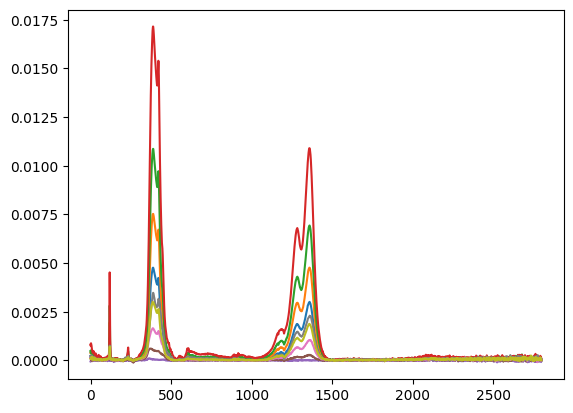

In [30]:
Y = YNO3_crystalA.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 96/96 [00:31<00:00,  3.07it/s]


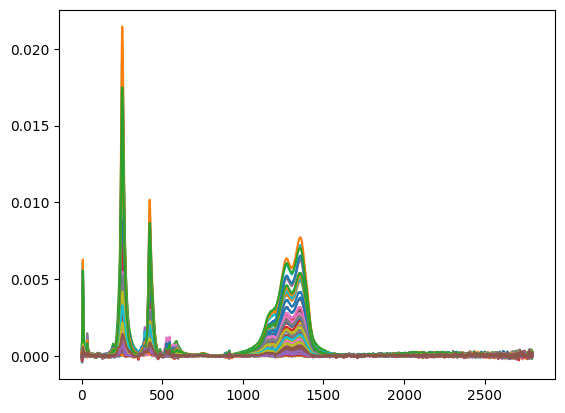

In [31]:
Y = YJAP_crystalA.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 9/9 [00:03<00:00,  2.34it/s]


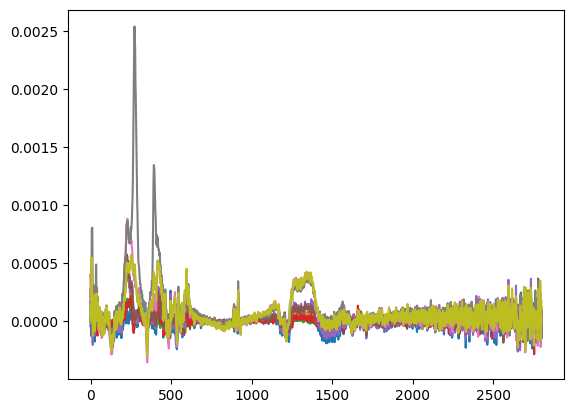

In [33]:
Y = Yamb_crystalA.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

In [34]:
Z = np.array(ZB)
chat_cv = loo_pca(Z,max_ncomp=Z.shape[1])[1]
mu, _, _, W = pca(Z)
W = W[:, :chat_cv]
print(chat_cv)

78


100%|██████████| 13/13 [00:33<00:00,  2.54s/it]


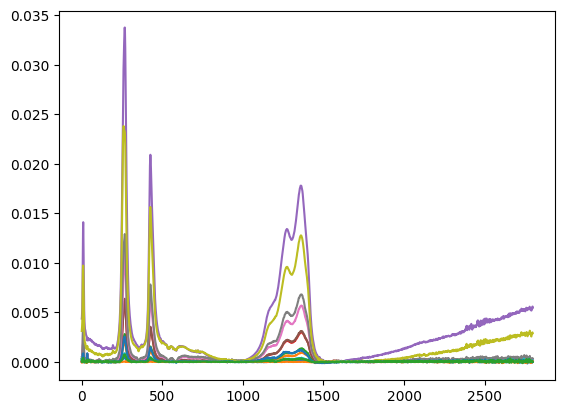

In [36]:
Y = YSO4_crystalB.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 9/9 [00:24<00:00,  2.71s/it]


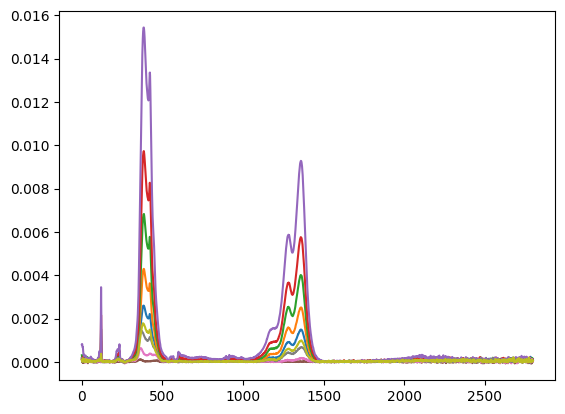

In [37]:
Y = YNO3_crystalB.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 87/87 [03:27<00:00,  2.39s/it]  


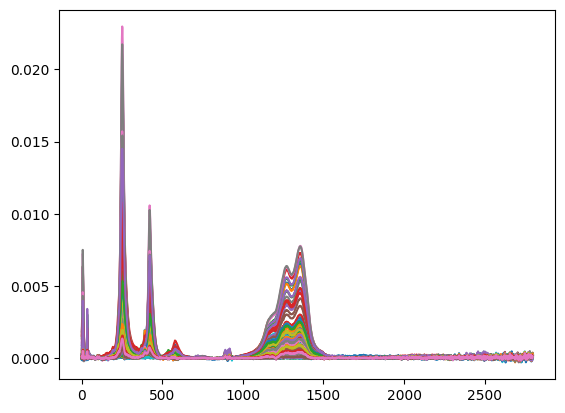

In [38]:
Y = YJAP_crystalB.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 8/8 [00:25<00:00,  3.15s/it]


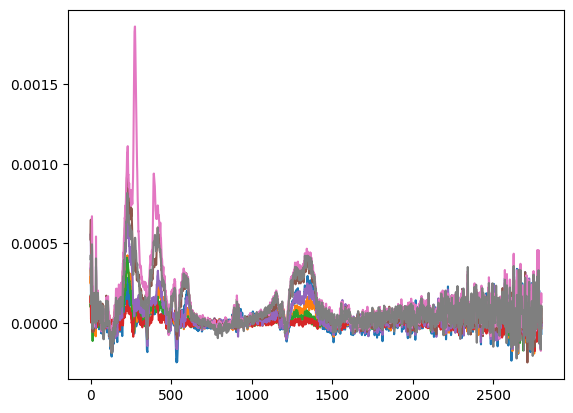

In [40]:
Y = Yamb_crystalB.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

In [62]:
Z = np.array(pd.concat([ZA,ZB]))
chat_cv = loo_pca(Z,max_ncomp=50)[1]
mu, _, _, W = pca(Z)
W = W[:, :chat_cv]
print(chat_cv)

39


100%|██████████| 14/14 [00:08<00:00,  1.70it/s]


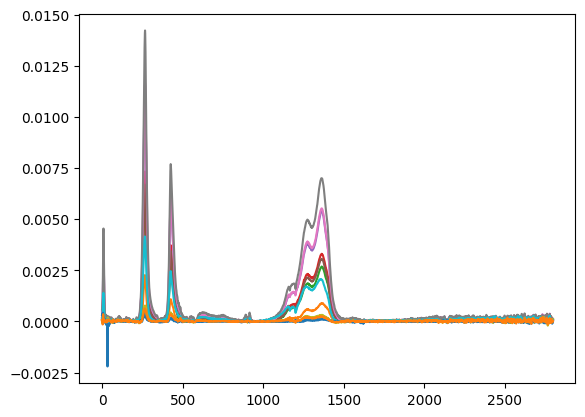

In [63]:
Y = YSO4_crystalA.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

100%|██████████| 13/13 [00:07<00:00,  1.64it/s]


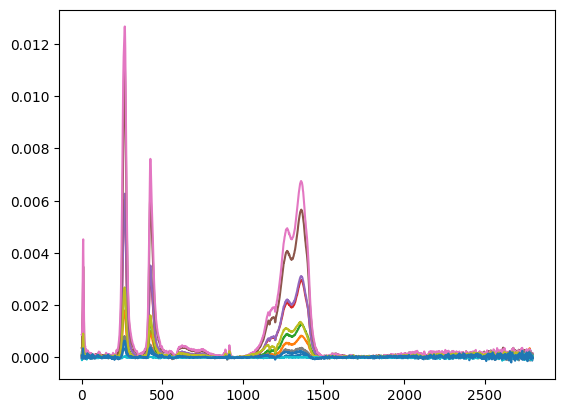

In [64]:
Y = YSO4_crystalB.copy()

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )    
                    
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_10_B':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_8_B':
        continue
    
    plt.plot(i["absorbance"])

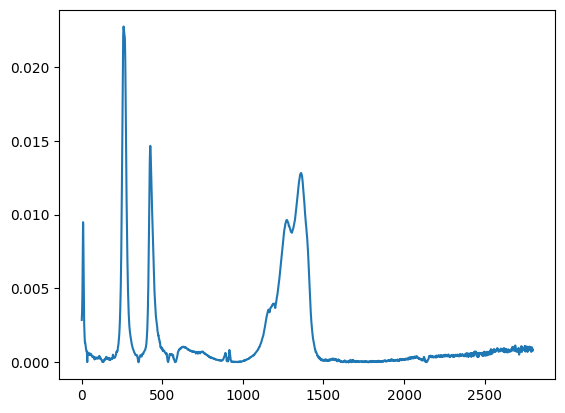

In [54]:
plt.plot(results[8]["absorbance"])

In [58]:
YSO4.index

Index(['20250603_ammoniumsulfate_calibration_1_A',
       '20250603_ammoniumsulfate_calibration_2_B',
       '20250603_ammoniumsulfate_calibration_3_A',
       '20250603_ammoniumsulfate_calibration_4_B',
       '20250603_ammoniumsulfate_calibration_5_A',
       '20250603_ammoniumsulfate_calibration_6_B',
       '20250603_ammoniumsulfate_calibration_7_A',
       '20250603_ammoniumsulfate_calibration_8_B',
       '20250603_ammoniumsulfate_calibration_9_A',
       '20250604_ammoniumsulfate_calibration_10_B',
       '20250604_ammoniumsulfate_calibration_1_A',
       '20250604_ammoniumsulfate_calibration_2_B',
       '20250604_ammoniumsulfate_calibration_3_A',
       '20250604_ammoniumsulfate_calibration_4_B',
       '20250604_ammoniumsulfate_calibration_5_A',
       '20250604_ammoniumsulfate_calibration_6_B',
       '20250604_ammoniumsulfate_calibration_7_A',
       '20250604_ammoniumsulfate_calibration_8_B',
       '20250604_ammoniumsulfate_calibration_9_A',
       '20250605_ammoniumsulfa

In [50]:
results[4]["sample_id"]

'20250604_ammoniumsulfate_calibration_10_B'

In [56]:
results[8]["sample_id"]

'20250604_ammoniumsulfate_calibration_8_B'

In [ ]:
def help_fun(Y,Z):
    Z = np.array(Z)
    chat_cv = loo_pca(Z)[1]
    mu, _, _, W = pca(Z)
    W = W[:, :chat_cv]

    distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
    with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )   
                    
    return mu, W, results

In [23]:
W.shape

(2799, 31)

In [21]:
ZA.shape

(126, 2799)

,601.7,603.7,605.6,607.5,609.5,611.4,613.3,615.2,617.2,619.1,...,5980.8,5982.7,5984.7,5986.6,5988.5,5990.5,5992.4,5994.3,5996.2,5998.2
20250806_exp02_1_A,1.670037,1.666207,1.665430,1.666744,1.668094,1.668465,1.667718,1.665204,1.659201,1.648730,...,1.475969,1.476638,1.477383,1.478074,1.478693,1.479347,1.480042,1.480725,1.481411,1.482106
20250806_exp02_2_B,1.678527,1.674603,1.673849,1.675280,1.676675,1.676940,1.676160,1.673706,1.667631,1.657042,...,1.478207,1.478967,1.479604,1.480213,1.480902,1.481673,1.482348,1.482935,1.483618,1.484366
20250807_exp02_1_A,1.672143,1.668196,1.667421,1.668917,1.670461,1.670933,1.670243,1.667818,1.661871,1.651377,...,1.478695,1.479383,1.480074,1.480711,1.481313,1.481985,1.482710,1.483470,1.484192,1.484852
20250807_exp02_2_B,1.676651,1.672797,1.672139,1.673592,1.674987,1.675391,1.674709,1.672292,1.666358,1.655856,...,1.477967,1.478595,1.479285,1.479940,1.480551,1.481261,1.481974,1.482619,1.483290,1.484013
20250807_exp02_3_A,1.671881,1.667915,1.667188,1.668742,1.670333,1.670805,1.670150,1.667803,1.661863,1.651323,...,1.478585,1.479309,1.479984,1.480598,1.481279,1.481954,1.482583,1.483266,1.483969,1.484674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20250901_exp01_5_A,1.679043,1.675182,1.674417,1.675882,1.677317,1.677484,1.676414,1.673613,1.667325,1.656607,...,1.487343,1.487970,1.488647,1.489325,1.490027,1.490789,1.491528,1.492248,1.492952,1.493586
20250901_exp01_6_B,1.685014,1.681229,1.680558,1.682014,1.683377,1.683535,1.682550,1.679834,1.673510,1.662613,...,1.487413,1.488103,1.488758,1.489410,1.490068,1.490793,1.491510,1.492135,1.492790,1.493457
20250901_exp01_7_A,1.679948,1.676155,1.675424,1.676800,1.678165,1.678334,1.677314,1.674559,1.668240,1.657432,...,1.488224,1.488880,1.489522,1.490262,1.491018,1.491678,1.492267,1.492895,1.493617,1.494346
20250901_exp01_8_B,1.684499,1.680638,1.679930,1.681418,1.682845,1.683090,1.682120,1.679352,1.673037,1.662152,...,1.486914,1.487547,1.488218,1.488916,1.489599,1.490260,1.490908,1.491574,1.492241,1.492889


In [7]:
Z = np.array(pd.concat([ZSO4_crystalA, ZSO4_crystalB], axis=0))

In [177]:
g = np.zeros(Z.shape[0])
g[ZSO4_crystalA.shape[0]:] = 1

In [278]:
c1 = 10
c2 = 1

In [8]:
def pca_residual(Z, mu,c):
    U, lam, V = svd(Z - mu, full_matrices=False)
    V = V.T
    W = (V * lam) / np.sqrt(Z.shape[0])
    W = W[:, :c]
    U = U[:, :c] * np.sqrt(Z.shape[0])
    
    E = Z - mu - U @ W.T
    
    return E, W

def help_fun(Y,Z):
    Z = np.array(Z)
    chat_cv = loo_pca(Z)[1]
    mu, _, _, W = pca(Z)
    W = W[:, :chat_cv]

    distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
    with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )   
                    
    return mu, W, results

In [470]:
spectra_dict = {"SO4A": np.array(ZSO4_crystalA),
                "SO4B": np.array(ZSO4_crystalB),
                "JAP": np.array(ZJAP),
                "NO3A": np.array(ZNO3_crystalA),
                "NO3B": np.array(ZNO3_crystalB)}

In [591]:
spectra_dict = {"SO4A": np.array(ZSO4_crystalA),
                "Other": np.vstack([np.array(ZSO4_crystalB),np.array(ZJAP),np.array(ZNO3_crystalA),np.array(ZNO3_crystalB)])}

In [593]:
g = []

for key in spectra_dict.keys():
    g.append(np.repeat(key,spectra_dict[key].shape[0]))
    
g = np.concatenate(g)

In [594]:
def gen_local_residuals(spectra_dict, local_dict):
    E = []
    
    for key in spectra_dict.keys():
        E.append(spectra_dict[key] - local_dict[key]["mu"] - local_dict[key]["U"] @ local_dict[key]["W"].T)
        
    E = np.vstack(E)
    return E

def run_pca(E,c):
    U, lam, V = svd(E, full_matrices=False)
    V = V.T
    W = (V * lam) / np.sqrt(E.shape[0])
    U = U * np.sqrt(E.shape[0])
    
    return U[:, :c], W[:, :c]
            

In [648]:
c1,c2 = 64,8

In [649]:
local_dict = {}
for key in spectra_dict.keys():
    local_dict[key] = {"mu":np.mean(spectra_dict[key], axis=0),"W":np.zeros([spectra_dict[key].shape[1],c1]),"U":np.zeros([spectra_dict[key].shape[0],c1])}

In [650]:
Err = 1000
tol = 1e-6
for i in range(100):
    E = gen_local_residuals(spectra_dict, local_dict)
    U,W = run_pca(E,c=c1)

    Err_new = np.sqrt(np.mean((E - U @ W.T)**2))  
    
    impr =   np.abs((Err - Err_new)/Err)
    print(i,impr)
    
    if  impr < tol:
        break
    Err = Err_new
   
    
    for key in spectra_dict.keys():
        idx = np.where(g == key)[0]
        E = spectra_dict[key] - local_dict[key]["mu"] - U[idx ,:] @ W.T
        local_dict[key]["U"],local_dict[key]["W"] = run_pca(E,c2)
        
    

0 0.999999986931035
1 0.074859290496763
2 0.001882543184597135
3 0.00047237796478528954
4 0.0003149104168225176
5 0.0002689778403609021
6 0.00024187114379996068
7 0.00022113115634767703
8 0.00020345055957633951
9 0.0001872507765985613
10 0.00017176661840962853
11 0.0001567672053769105
12 0.00014231720993587816
13 0.00012858914993010509
14 0.00011575015861555954
15 0.00010391306646701999
16 9.312809592627626e-05
17 8.339354035922796e-05
18 7.467146078495197e-05
19 6.690169139228963e-05
20 6.00121592057766e-05
21 5.3925774620865664e-05
22 4.856481724112647e-05
23 4.385367773775641e-05
24 3.9720552452797165e-05
25 3.609845493278242e-05
26 3.292576078874375e-05
27 3.0146422533239302e-05
28 2.770994987028936e-05
29 2.5571227408133905e-05
30 2.3690225442418167e-05
31 2.2031646269670452e-05
32 2.0564537445685214e-05
33 1.926189446899789e-05
34 1.8100268319471367e-05
35 1.7059388046870028e-05
36 1.6121804800975517e-05
37 1.527256095266416e-05
38 1.4498886082264962e-05
39 1.3789920292735035e-05

In [11]:
Zt =  ZSO4_crystalA
Zs = np.vstack([np.array(ZSO4_crystalB),np.array(ZJAP),np.array(ZNO3_crystalA),np.array(ZNO3_crystalB)])

In [18]:
def help_fun(Y,Z):
    Z = np.array(Z)
    chat_cv = loo_pca(Z)[1]
    mu, _, _, W = pca(Z)
    W = W[:, :chat_cv]
    print(chat_cv)

    distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
    with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )   
    
    E = np.array([i["absorbance"] for i in results])
    chat_cv = loo_pca(E)[1]
    print(chat_cv)
    mu1, _, _, W1 = pca(E)
    
    mu = mu + mu1                    
    W = np.hstack([W, W1])
        
    return mu, W, results

In [24]:
Zt = ZJAP
Zs = np.vstack([np.array(ZSO4_crystalB),np.array(ZSO4_crystalA),np.array(ZNO3_crystalA),np.array(ZNO3_crystalB)])

In [25]:
mu, W, res = help_fun(Zt,Zs)

21


100%|██████████| 183/183 [00:08<00:00, 22.06it/s]


12


In [21]:
# key = "SO4A"
# mu = local_dict[key]["mu"]
# Wk = np.hstack((local_dict[key]["W"], W))

In [ ]:
Z = np.array(ZJAP)
chat_cv = loo_pca(Z, max_ncomp=Z.shape[0])[1]

In [42]:
mu, _, _, W = pca(Z)
W = W[:, :chat_cv]

In [46]:
#Y = YSO4_crystalA.copy()
Y = YJAP.copy().iloc[:20,:]

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
#distribute_args = [(np.array(Y.iloc[i])[:1500], mu[:1500], W[:1500, :], 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )   

100%|██████████| 20/20 [00:48<00:00,  2.43s/it]


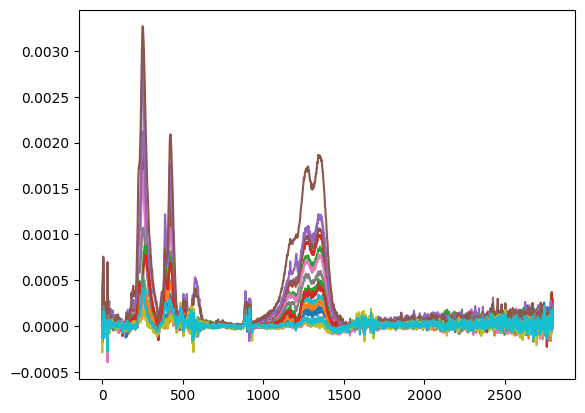

In [47]:
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"])

In [41]:
chat_cv

np.int64(108)

In [39]:
Z.shape[0]

183

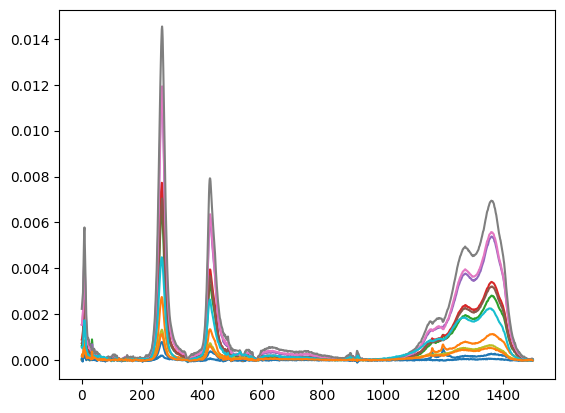

In [364]:
for i in results:
    if i["sample_id"] =='20250604_ammoniumsulfate_calibration_7_A':
        continue
    if i["sample_id"] == '20250604_ammoniumsulfate_calibration_9_A':
        continue
    plt.plot(i["absorbance"][:1500])

In [8]:
airmon_SO4 = {}

In [ ]:

    
    
    # for i in tqdm(range(len(results))):
    #     boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), np.array(ZSO4_crystalA), results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
        
    #     alpha = 0.01
    #     stdev = np.std(boot_a, axis=0)
    #     r = results[i]["absorbance"]- boot_a
    #     crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    #     LOD = crit*stdev
        
    #     results[i]["alpha"] = alpha
    #     results[i]["stdev"] = stdev
    #     results[i]["crit"] = crit
    #     results[i]["LOD"] = LOD

 

In [62]:
Z1 = ZSO4_crystalA
Z2 = pd.concat((ZSO4_crystalB,ZNO3_crystalB,ZJAP,ZNO3_crystalA),ignore_index=True)

In [63]:
res = help_fun(Z1,Z2)
#res = help_fun(ZSO4_crystalA,ZJAP)
E = np.array([i["absorbance"] for i in res])

chat_cv = loo_pca(E)[1]
mu1, lam, V, W1 = pca(E)
W1 = W1[:, :chat_cv]

Z2 = np.array(Z2)
chat_cv = loo_pca(Z2)[1]
mu, lam, V, W = pca(Z2)
W = W[:, :chat_cv]

mu = mu + mu1
W = np.hstack((W,W1))

100%|██████████| 13/13 [00:06<00:00,  2.01it/s]


In [68]:
ZJAP

,601.7,603.7,605.6,607.5,609.5,611.4,613.3,615.2,617.2,619.1,...,5980.8,5982.7,5984.7,5986.6,5988.5,5990.5,5992.4,5994.3,5996.2,5998.2
20250806_exp02_1_A,1.668944,1.665000,1.664109,1.665413,1.666845,1.667223,1.666506,1.664163,1.658363,1.648043,...,1.476007,1.476672,1.477401,1.478029,1.478625,1.479352,1.480098,1.480738,1.481351,1.482074
20250806_exp02_2_B,1.678356,1.674383,1.673608,1.675019,1.676389,1.676665,1.675904,1.673521,1.667641,1.657265,...,1.478545,1.479250,1.479780,1.480351,1.481067,1.481781,1.482494,1.483175,1.483769,1.484412
20250807_exp02_1_A,1.674270,1.670447,1.669658,1.671068,1.672475,1.672663,1.671656,1.668983,1.662876,1.652189,...,1.478134,1.478795,1.479451,1.480132,1.480780,1.481472,1.482164,1.482842,1.483552,1.484195
20250807_exp02_2_B,1.678876,1.675124,1.674346,1.675701,1.677032,1.677206,1.676245,1.673562,1.667366,1.656656,...,1.477518,1.478228,1.478922,1.479581,1.480277,1.480950,1.481628,1.482283,1.482883,1.483567
20250807_exp02_3_A,1.674061,1.670279,1.669565,1.671021,1.672365,1.672540,1.671502,1.668706,1.662570,1.651956,...,1.477915,1.478592,1.479314,1.479997,1.480671,1.481358,1.482038,1.482739,1.483419,1.484048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20250901_exp01_5_A,1.682008,1.678367,1.677790,1.679127,1.680323,1.680305,1.678962,1.675892,1.669432,1.658487,...,1.487771,1.488456,1.489136,1.489779,1.490419,1.491040,1.491681,1.492411,1.493139,1.493822
20250901_exp01_6_B,1.687383,1.683670,1.683089,1.684524,1.685717,1.685626,1.684337,1.681306,1.674728,1.663704,...,1.486935,1.487617,1.488281,1.488926,1.489565,1.490275,1.491009,1.491663,1.492269,1.492941
20250901_exp01_7_A,1.680760,1.677063,1.676384,1.677724,1.678958,1.679001,1.677771,1.674747,1.668315,1.657454,...,1.487035,1.487719,1.488415,1.489059,1.489720,1.490419,1.491095,1.491806,1.492524,1.493198
20250901_exp01_8_B,1.686817,1.683089,1.682457,1.683847,1.685010,1.684931,1.683721,1.680804,1.674280,1.663213,...,1.486374,1.487155,1.487853,1.488510,1.489191,1.489838,1.490476,1.491195,1.491925,1.492614


In [72]:
ZJAP_crystalA = ZJAP[ZJAP.index.astype(str).str.endswith("A")].copy()

In [82]:
Z2 = pd.concat((ZSO4_crystalA,ZNO3_crystalA,ZSO4_crystalB,ZNO3_crystalB,ZJAP),ignore_index=True)
Z2 = np.array(Z2)
chat_cv = loo_pca(Z2)[1]
mu, lam, V, W = pca(Z2)
W = W[:, :chat_cv]

100%|██████████| 14/14 [00:07<00:00,  1.85it/s]


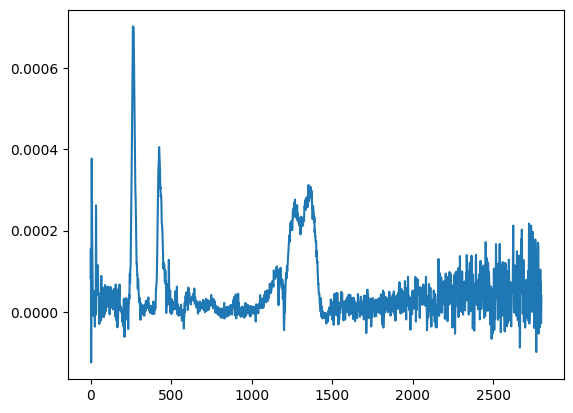

In [105]:
plt.plot(results[13]["absorbance"])

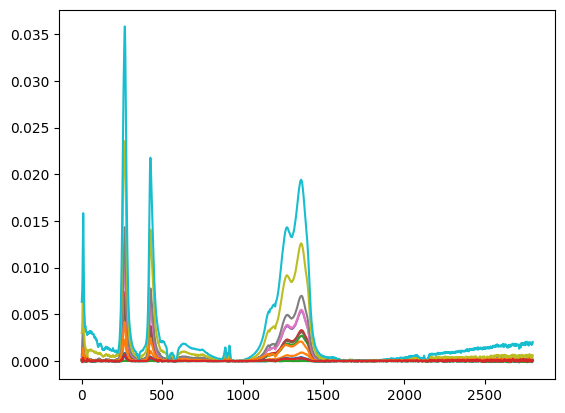

In [86]:
for i in results:
    plt.plot(i["absorbance"])

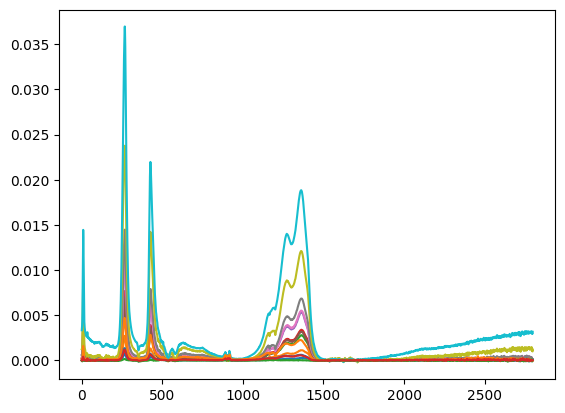

In [77]:
for i in results:
    plt.plot(i["absorbance"])

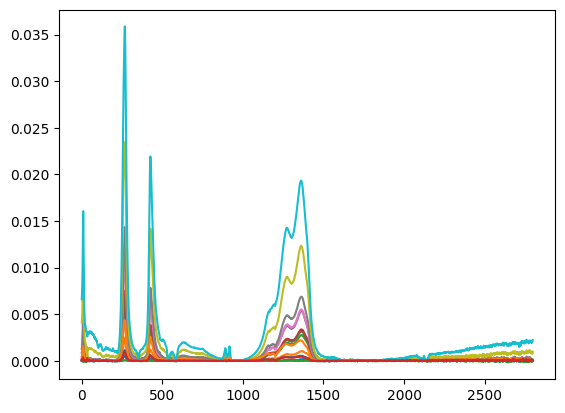

In [80]:
for i in results:
    plt.plot(i["absorbance"])

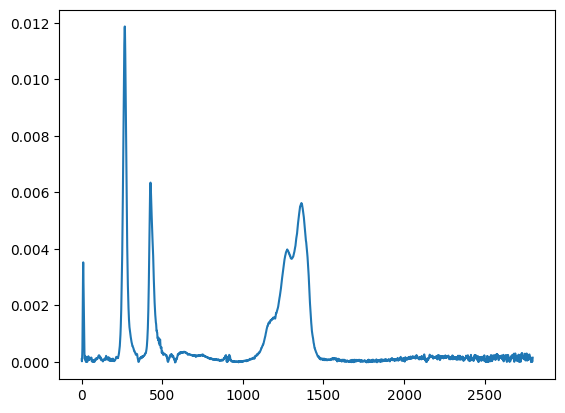

In [67]:
plt.plot(results[6]["absorbance"])

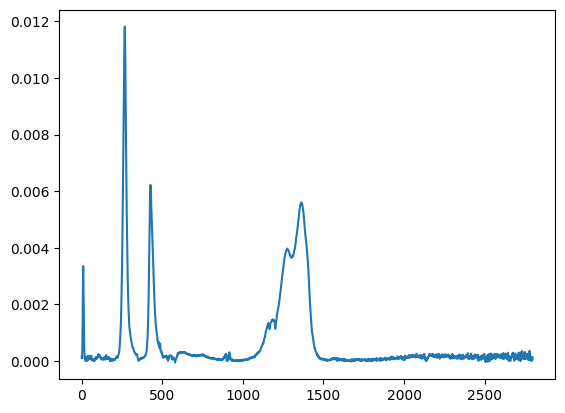

In [61]:
plt.plot(results[6]["absorbance"])

In [46]:
W1.shape

(2799, 5)

In [10]:
Z = pd.concat((ZSO4_crystalA,ZSO4_crystalB,ZNO3_crystalA,ZNO3_crystalB,ZJAP),ignore_index=True)
Z = np.array(Z)

In [11]:
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

In [17]:
Y = YSO4_crystalB

distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )   

100%|██████████| 13/13 [00:06<00:00,  1.88it/s]


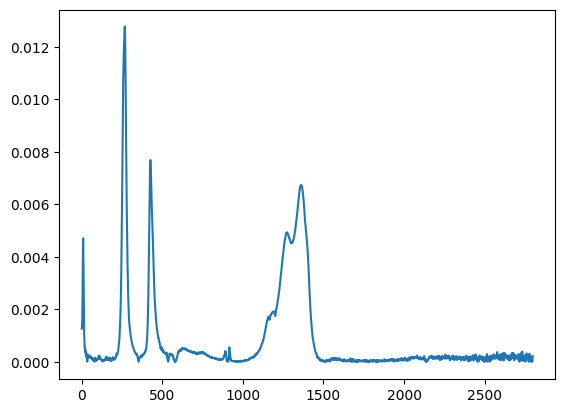

In [26]:
plt.plot(results[7]["absorbance"])

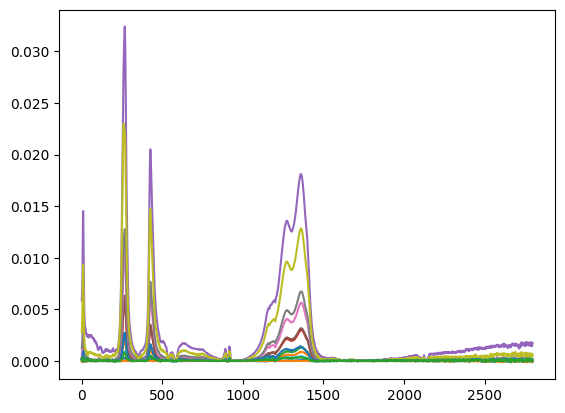

In [22]:
for i in results:
    plt.plot(i["absorbance"])

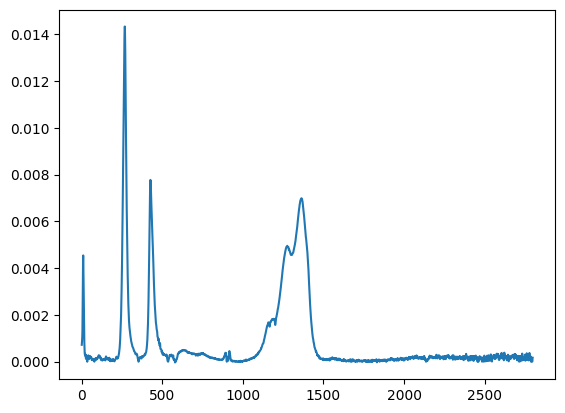

In [ ]:
airmon_SO4 = {}
airmon_SO4["SO4_crystalA"] = help_fun(YSO4_crystalA,ZSO4_crystalA)
airmon_SO4["SO4+NO3_crystalA"] = help_fun(YSO4_crystalA,pd.concat([ZSO4_crystalA, ZNO3_crystalA]))
airmon_SO4["Japan"] = help_fun(YSO4_crystalA,ZJAP)
airmon_SO4["NO3_crystalA"] = help_fun(YSO4_crystalA,ZNO3_crystalA)
airmon_SO4["NO3_crystalA+B"] = help_fun(YSO4_crystalA,pd.concat([ZNO3_crystalA, ZNO3_crystalB]))
airmon_SO4["SO4+NO3_crystalA+B"] = help_fun(YSO4_crystalA,pd.concat([ZNO3_crystalA, ZNO3_crystalB, ZSO4_crystalA, ZSO4_crystalB]))

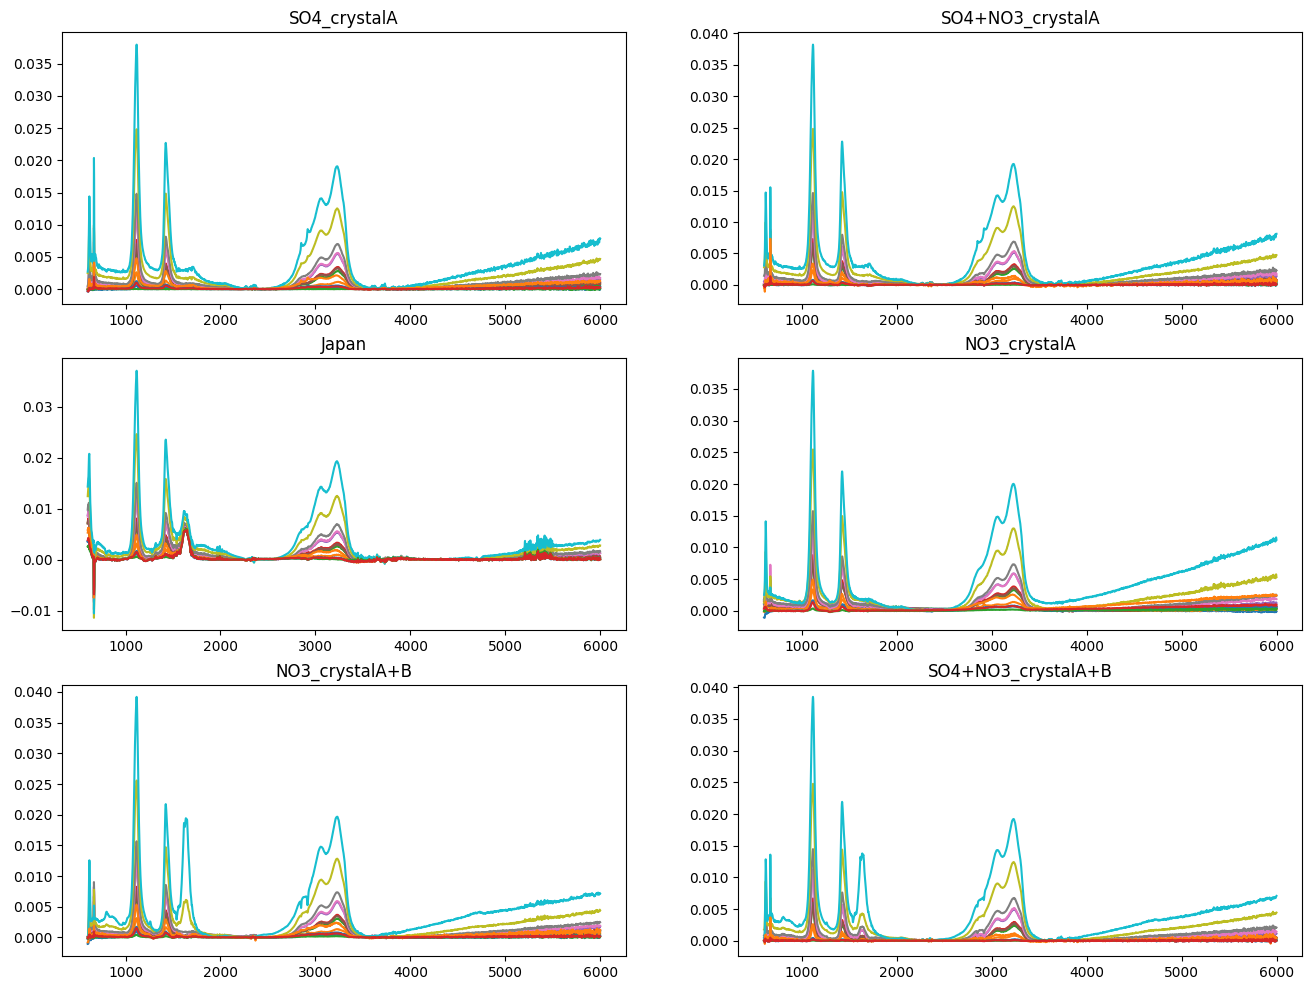

In [82]:
nrows = 3
fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows))

for idx, key in enumerate(airmon_SO4):
    row = (idx // 2)
    
    if idx % 2 == 0:
        col = 0
    else:
        col = 1
        
    for i in airmon_SO4[key]:
        axes[row][col].plot(wn, i["absorbance"])
    axes[row][col].set_title(f"{key}")

In [83]:
airmon_NO3 = {}
airmon_NO3["SO4_crystalA"] = help_fun(YNO3_crystalA,ZSO4_crystalA)
airmon_NO3["SO4+NO3_crystalA"] = help_fun(YNO3_crystalA,pd.concat([ZSO4_crystalA, ZNO3_crystalA]))
airmon_NO3["Japan"] = help_fun(YNO3_crystalA,ZJAP)
airmon_NO3["NO3_crystalA"] = help_fun(YNO3_crystalA,ZNO3_crystalA)
airmon_NO3["NO3_crystalA+B"] = help_fun(YNO3_crystalA,pd.concat([ZNO3_crystalA, ZNO3_crystalB]))
airmon_NO3["SO4+NO3_crystalA+B"] = help_fun(YNO3_crystalA,pd.concat([ZNO3_crystalA, ZNO3_crystalB, ZSO4_crystalA, ZSO4_crystalB]))

100%|██████████| 9/9 [00:01<00:00,  4.63it/s]


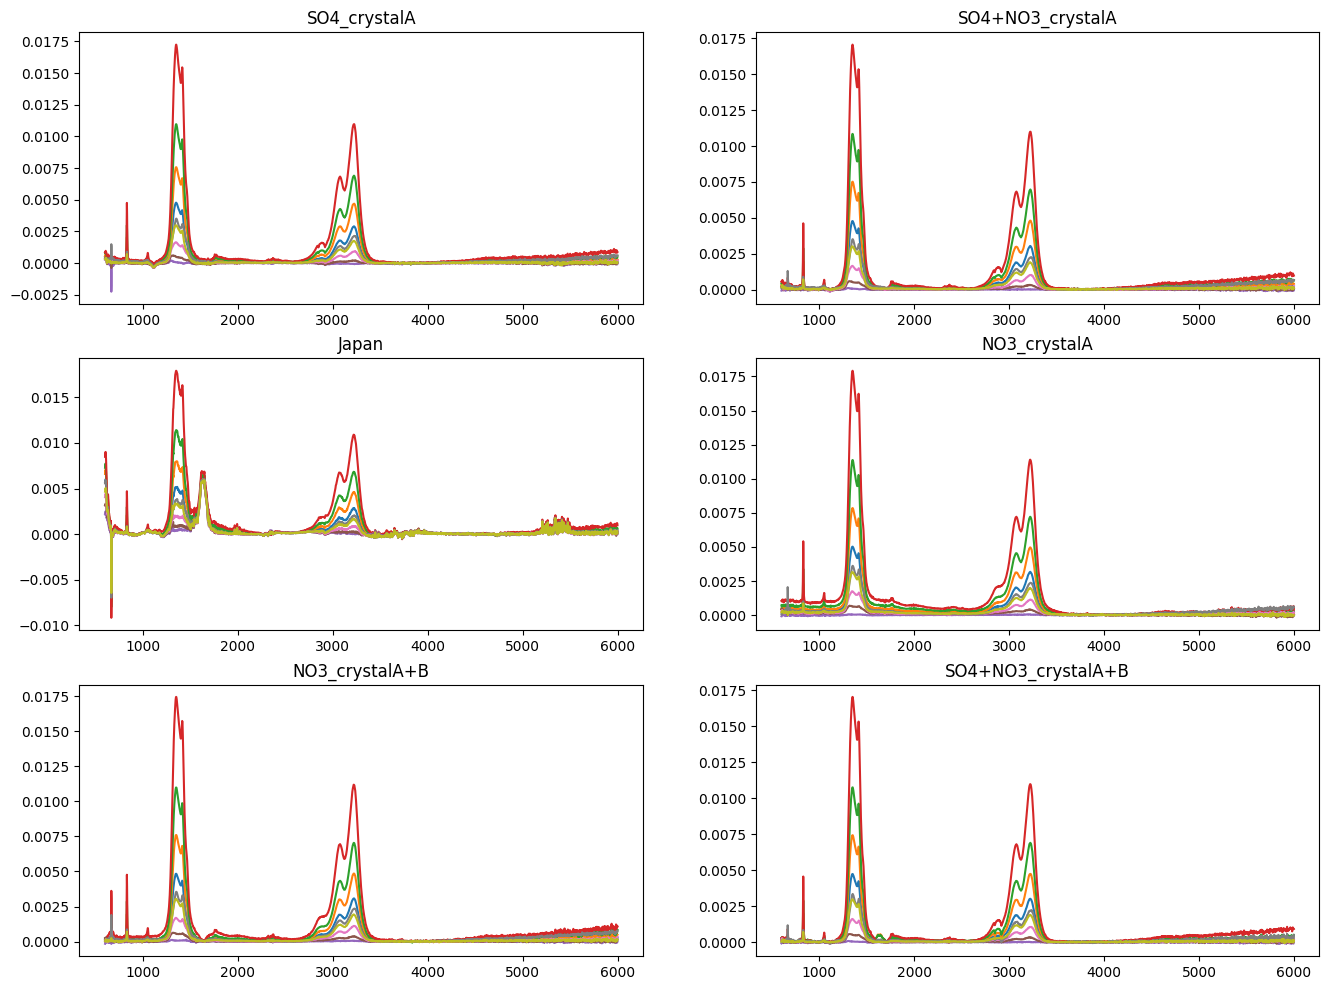

In [84]:
nrows = 3
fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows))

for idx, key in enumerate(airmon_SO4):
    row = (idx // 2)
    
    if idx % 2 == 0:
        col = 0
    else:
        col = 1
        
    for i in airmon_NO3[key]:
        axes[row][col].plot(wn, i["absorbance"])
    axes[row][col].set_title(f"{key}")

100%|██████████| 13/13 [00:01<00:00,  9.76it/s]


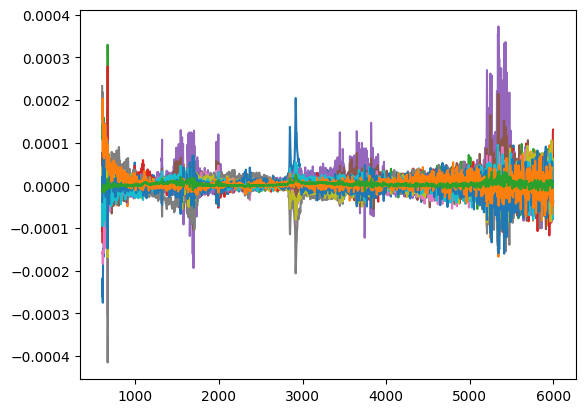

In [93]:
res = help_fun(ZSO4_crystalA,ZSO4_crystalA)
for i in res:
    plt.plot(wn, i["absorbance"])

100%|██████████| 13/13 [00:01<00:00,  9.15it/s]


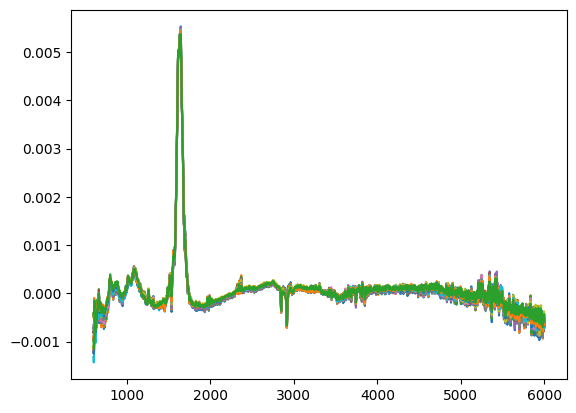

In [94]:
res = help_fun(ZSO4_crystalA,ZSO4_crystalB)
for i in res:
    plt.plot(wn, i["absorbance"])

100%|██████████| 13/13 [00:01<00:00,  9.94it/s]


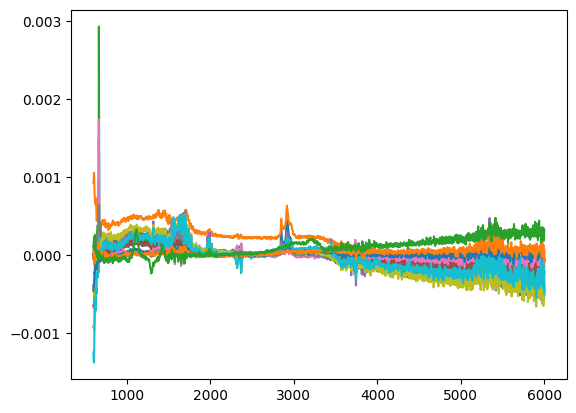

In [95]:
res = help_fun(ZSO4_crystalA,ZNO3_crystalA)
for i in res:
    plt.plot(wn, i["absorbance"])

100%|██████████| 13/13 [00:01<00:00, 10.00it/s]


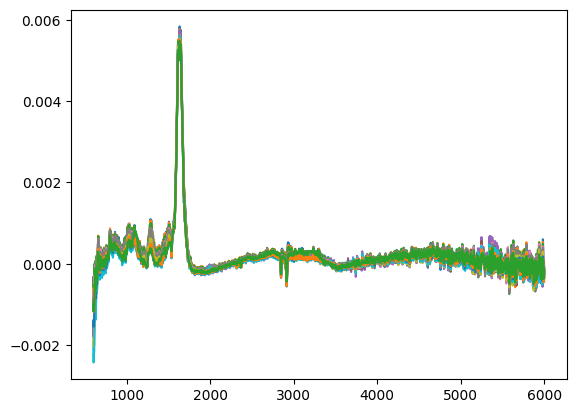

In [142]:
res = help_fun(ZSO4_crystalA,ZNO3_crystalB)
for i in res:
    plt.plot(wn, i["absorbance"])

100%|██████████| 13/13 [00:02<00:00,  6.23it/s]


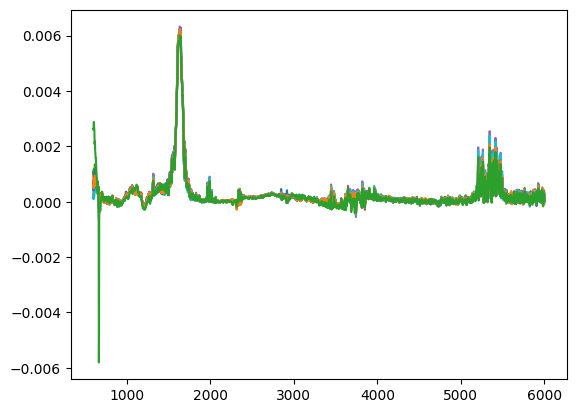

In [143]:
res = help_fun(ZSO4_crystalA,ZJAP)
for i in res:
    plt.plot(wn, i["absorbance"])

In [150]:
E = np.array([i["absorbance"] for i in res])
drift = np.mean(E, axis=0)

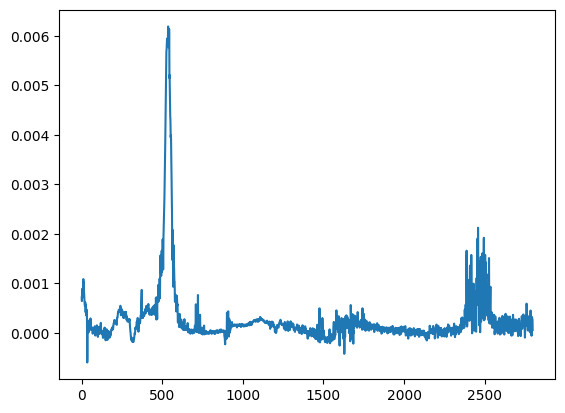

In [156]:
plt.plot(drift)

In [152]:
res = help_fun(YSO4_crystalA,ZJAP)

100%|██████████| 14/14 [00:02<00:00,  6.86it/s]


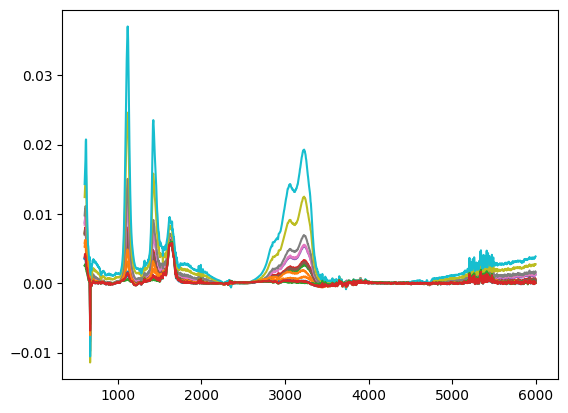

In [157]:
for i in res:
    plt.plot(wn, i["absorbance"])

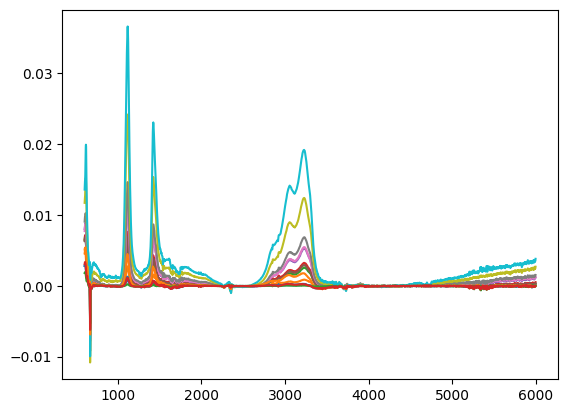

In [154]:
for i in res:
    plt.plot(wn, i["absorbance"]-drift)

In [183]:
y = np.array(YSO4_crystalA.loc["20250603_ammoniumsulfate_calibration_7_A"])

In [184]:
z = np.array(ZSO4_crystalA.loc["20250603_ammoniumsulfate_calibration_7_A"])

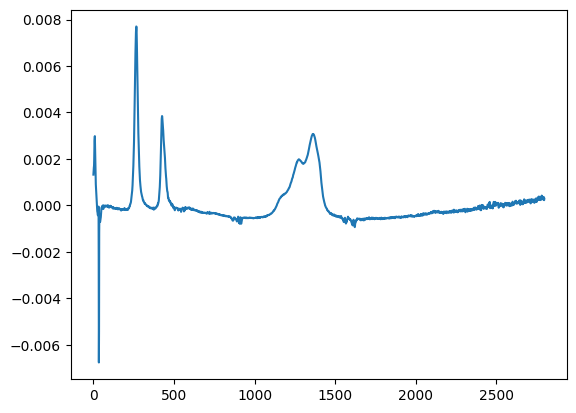

In [185]:
plt.plot(y-z)

In [186]:
Z = np.array(ZJAP)
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

In [187]:
c1 = distribute_veb((y, mu, W, 1e-5, 0.5 + 1e-5, "PB", " "))
c2 = distribute_veb((z, mu, W, 1e-5, 0.5 + 1e-5, "PB", " "))

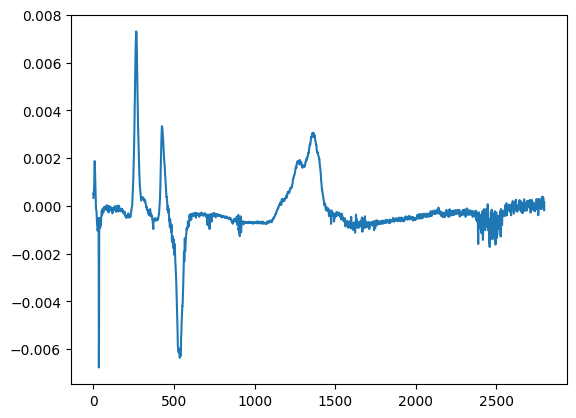

In [192]:
#plt.plot(y-z)
plt.plot(y - (z + c2["absorbance"]))

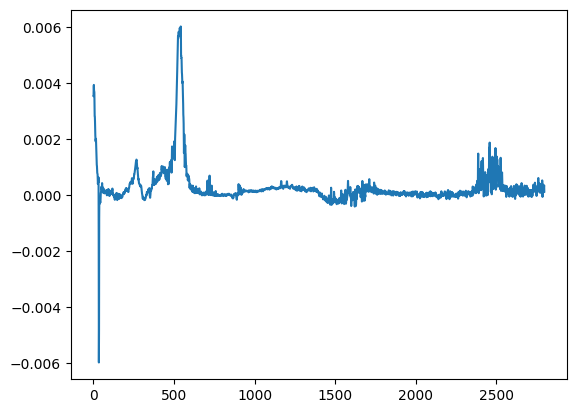

In [176]:
plt.plot(c1["absorbance"])

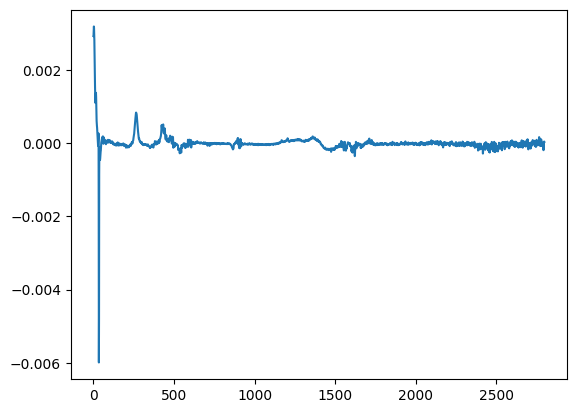

In [ ]:


    distribute_args = [(np.array(Y.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", Y.iloc[i].name) for i in range(len(Y))] 
    with mp.Pool(processes=mp.cpu_count()) as pool:
                    results = list(
                        tqdm(
                            pool.imap(distribute_veb, distribute_args),
                            total=len(distribute_args),
                        )
                    )   

In [158]:
YSO4_crystalA

,601.7,603.7,605.6,607.5,609.5,611.4,613.3,615.2,617.2,619.1,...,5980.8,5982.7,5984.7,5986.6,5988.5,5990.5,5992.4,5994.3,5996.2,5998.2
20250603_ammoniumsulfate_calibration_1_A,1.673804,1.669962,1.669338,1.670701,1.671974,1.672181,1.671198,1.668188,1.661556,1.650921,...,1.466727,1.467401,1.468071,1.468649,1.469235,1.469963,1.470659,1.471317,1.472049,1.472730
20250603_ammoniumsulfate_calibration_3_A,1.674195,1.670449,1.669810,1.671167,1.672505,1.672753,1.671797,1.668942,1.662492,1.651846,...,1.467111,1.467852,1.468551,1.469210,1.469884,1.470563,1.471185,1.471815,1.472498,1.473213
20250603_ammoniumsulfate_calibration_5_A,1.674055,1.670294,1.669653,1.671070,1.672519,1.672899,1.672169,1.669546,1.663305,1.652851,...,1.466693,1.467339,1.468020,1.468705,1.469410,1.470096,1.470715,1.471312,1.471993,1.472749
20250603_ammoniumsulfate_calibration_7_A,1.673744,1.669963,1.669341,1.670777,1.672212,1.672688,1.672156,1.669672,1.663482,1.652952,...,1.466855,1.467536,1.468230,1.468896,1.469580,1.470289,1.470970,1.471622,1.472295,1.472991
20250603_ammoniumsulfate_calibration_9_A,1.673673,1.669852,1.669167,1.670657,1.672247,1.672966,1.672673,1.670368,1.664394,1.654089,...,1.467214,1.467870,1.468496,1.469212,1.469947,1.470638,1.471294,1.471961,1.472647,1.473290
20250604_ammoniumsulfate_calibration_1_A,1.671732,1.667884,1.667172,1.668579,1.670099,1.670674,1.670121,1.667609,1.661512,1.651162,...,1.466314,1.467003,1.467647,1.468343,1.469033,1.469671,1.470346,1.471050,1.471714,1.472344
20250604_ammoniumsulfate_calibration_3_A,1.674831,1.671078,1.670471,1.671905,1.673491,1.674214,1.673880,1.671540,1.665559,1.655279,...,1.468842,1.469479,1.470149,1.470846,1.471524,1.472235,1.472935,1.473592,1.474207,1.474847
20250604_ammoniumsulfate_calibration_5_A,1.673038,1.669345,1.668729,1.670192,1.671829,1.672664,1.672472,1.670373,1.664653,1.654430,...,1.467956,1.468629,1.469254,1.469928,1.470634,1.471297,1.471984,1.472691,1.473363,1.473993
20250604_ammoniumsulfate_calibration_7_A,1.668490,1.664738,1.664131,1.665891,1.668124,1.669799,1.670572,1.669131,1.663796,1.653756,...,1.468046,1.468743,1.469391,1.470046,1.470685,1.471377,1.472097,1.472746,1.473391,1.474107
20250604_ammoniumsulfate_calibration_9_A,1.669375,1.665776,1.665388,1.667262,1.669647,1.671839,1.673407,1.672751,1.668092,1.658472,...,1.473997,1.474652,1.475288,1.475938,1.476660,1.477374,1.478077,1.478776,1.479437,1.480163


In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns

for i in airmon_SO4["loaded_crystal_A"]["SO4_cleaned_crystal_A"]:
    axs[0, 0].plot(wn, i["absorbance"])
axs[0, 0].set_title("SO4 cleaned crystal A")

for i in airmon_SO4["loaded_crystal_A"]["SO4_NO3_cleaned_crystal_A"]:
    axs[0, 1].plot(wn, i["absorbance"])
axs[0, 1].set_title("SO4 + NO3 cleaned crystal A")
    
for i in airmon_SO4["loaded_crystal_A"]["NO3_cleaned_crystal_A"]:
    axs[1, 0].plot(wn, i["absorbance"])
axs[1, 0].set_title("NO3 cleaned crystal A")
    
for i in airmon_SO4["loaded_crystal_A"]["cleaned_crystal_Jap"]:
    axs[1, 1].plot(wn, i["absorbance"])
axs[1, 1].set_title("Cleaned crystal Japan")

for i in airmon_SO4["loaded_crystal_A"]["cleaned_crystal_Jap"]:
    axs[1, 1].plot(wn, i["absorbance"])
axs[1, 1].set_title("Cleaned crystal Japan")

for i in airmon_SO4["loaded_crystal_A"]["NO3_cleaned_crystal_A+B"]:
    axs[2, 0].plot(wn, i["absorbance"])
axs[2, 0].set_title("NO3 cleaned crystal A+B")

for i in airmon_SO4["loaded_crystal_A"]["NO3_SO4_cleaned_crystal_A+B"]:
    axs[2, 1].plot(wn, i["absorbance"])
axs[2, 1].set_title("NO3 + SO4 cleaned crystal A+B")

plt.tight_layout()
plt.show()

In [ ]:
pd.concat([ZNO3_crystalA, ZNO3_crystalB])

In [ ]:
Z = np.array()

In [ ]:
Z = np.array(ZJAP)

In [ ]:
aa

In [26]:
chat_cv = loo_pca(np.array(ZSO4_crystalA))[1]
mu, lam, V, W = pca(np.array(ZSO4_crystalA))
W = W[:, :chat_cv]

distribute_args = [(np.array(YSO4_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YSO4_crystalA.iloc[i].name) for i in range(len(YSO4_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), np.array(ZSO4_crystalA), results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD

airmon_SO4["loaded_crystal_A"]["SO4_cleaned_crystal_A"] = results

100%|██████████| 14/14 [00:51<00:00,  3.66s/it]


In [27]:
Z = np.array(pd.concat([ZSO4_crystalA, ZNO3_crystalA]))

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YSO4_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YSO4_crystalA.iloc[i].name) for i in range(len(YSO4_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_SO4["loaded_crystal_A"]["SO4_NO3_cleaned_crystal_A"] = results

100%|██████████| 14/14 [01:28<00:00,  6.34s/it]


In [30]:
Z = np.array(ZJAP)

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YSO4_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YSO4_crystalA.iloc[i].name) for i in range(len(YSO4_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_SO4["loaded_crystal_A"]["cleaned_crystal_Jap"] = results

100%|██████████| 14/14 [03:37<00:00, 15.57s/it]


In [35]:
Z = np.array(ZNO3_crystalA)

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YSO4_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YSO4_crystalA.iloc[i].name) for i in range(len(YSO4_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_SO4["loaded_crystal_A"]["NO3_cleaned_crystal_A"] = results

100%|██████████| 14/14 [00:44<00:00,  3.17s/it]


In [37]:
Z = np.array(pd.concat([ZNO3_crystalA, ZNO3_crystalB]))

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YSO4_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YSO4_crystalA.iloc[i].name) for i in range(len(YSO4_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_SO4["loaded_crystal_A"]["NO3_cleaned_crystal_A+B"] = results

100%|██████████| 14/14 [00:57<00:00,  4.12s/it]


In [42]:
Z = np.array(pd.concat([ZNO3_crystalA, ZNO3_crystalB, ZSO4_crystalA, ZSO4_crystalB]))

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YSO4_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YSO4_crystalA.iloc[i].name) for i in range(len(YSO4_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YSO4_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_SO4["loaded_crystal_A"]["NO3_SO4_cleaned_crystal_A+B"] = results

100%|██████████| 14/14 [01:41<00:00,  7.24s/it]


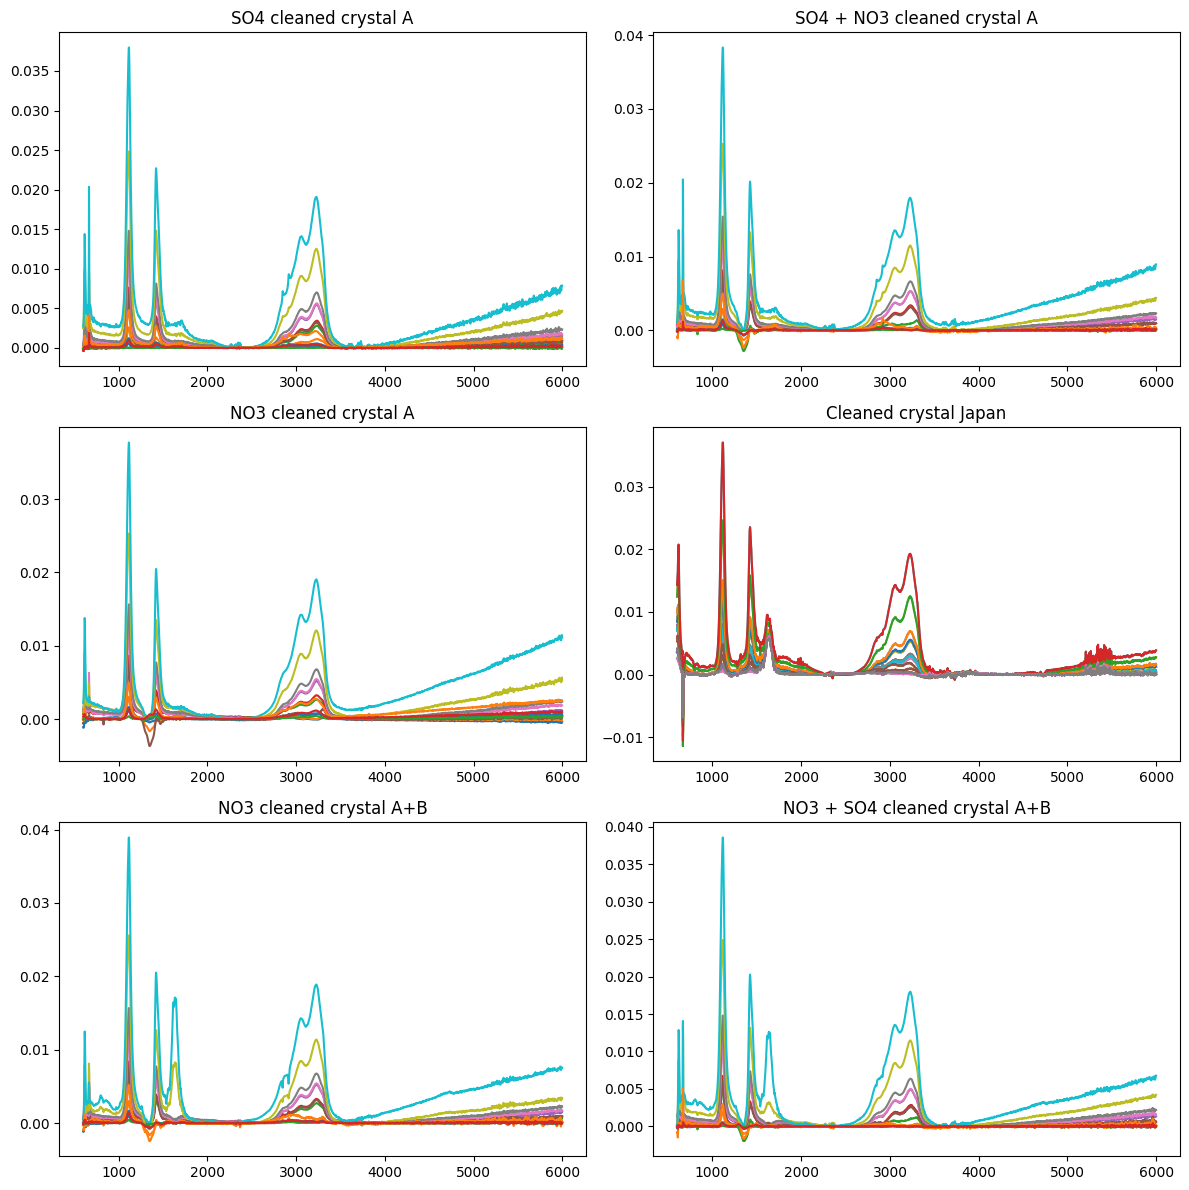

In [43]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns

for i in airmon_SO4["loaded_crystal_A"]["SO4_cleaned_crystal_A"]:
    axs[0, 0].plot(wn, i["absorbance"])
axs[0, 0].set_title("SO4 cleaned crystal A")

for i in airmon_SO4["loaded_crystal_A"]["SO4_NO3_cleaned_crystal_A"]:
    axs[0, 1].plot(wn, i["absorbance"])
axs[0, 1].set_title("SO4 + NO3 cleaned crystal A")
    
for i in airmon_SO4["loaded_crystal_A"]["NO3_cleaned_crystal_A"]:
    axs[1, 0].plot(wn, i["absorbance"])
axs[1, 0].set_title("NO3 cleaned crystal A")
    
for i in airmon_SO4["loaded_crystal_A"]["cleaned_crystal_Jap"]:
    axs[1, 1].plot(wn, i["absorbance"])
axs[1, 1].set_title("Cleaned crystal Japan")

for i in airmon_SO4["loaded_crystal_A"]["cleaned_crystal_Jap"]:
    axs[1, 1].plot(wn, i["absorbance"])
axs[1, 1].set_title("Cleaned crystal Japan")

for i in airmon_SO4["loaded_crystal_A"]["NO3_cleaned_crystal_A+B"]:
    axs[2, 0].plot(wn, i["absorbance"])
axs[2, 0].set_title("NO3 cleaned crystal A+B")

for i in airmon_SO4["loaded_crystal_A"]["NO3_SO4_cleaned_crystal_A+B"]:
    axs[2, 1].plot(wn, i["absorbance"])
axs[2, 1].set_title("NO3 + SO4 cleaned crystal A+B")

plt.tight_layout()
plt.show()

In [78]:
airmon_NO3 = {}
airmon_NO3["loaded_crystal_A"] = {}

In [79]:
chat_cv = loo_pca(np.array(ZSO4_crystalA))[1]
mu, lam, V, W = pca(np.array(ZSO4_crystalA))
W = W[:, :chat_cv]

distribute_args = [(np.array(YNO3_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YNO3_crystalA.iloc[i].name) for i in range(len(YNO3_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YNO3_crystalA.loc[results[i]["sample_id"]].to_numpy(), np.array(ZSO4_crystalA), results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD

airmon_NO3["loaded_crystal_A"]["SO4_cleaned_crystal_A"] = results

100%|██████████| 9/9 [00:28<00:00,  3.19s/it]


In [80]:
Z = np.array(ZNO3_crystalA)

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YNO3_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YNO3_crystalA.iloc[i].name) for i in range(len(YNO3_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YNO3_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_NO3["loaded_crystal_A"]["NO3_cleaned_crystal_A"] = results

100%|██████████| 9/9 [00:25<00:00,  2.86s/it]


In [81]:
Z = np.array(pd.concat([ZNO3_crystalA, ZNO3_crystalB]))

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
W = W[:, :chat_cv]

distribute_args = [(np.array(YNO3_crystalA.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YNO3_crystalA.iloc[i].name) for i in range(len(YNO3_crystalA))] 
with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YNO3_crystalA.loc[results[i]["sample_id"]].to_numpy(), Z, results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_NO3["loaded_crystal_A"]["NO3_cleaned_crystal_A+B"] = results

100%|██████████| 9/9 [00:36<00:00,  4.03s/it]


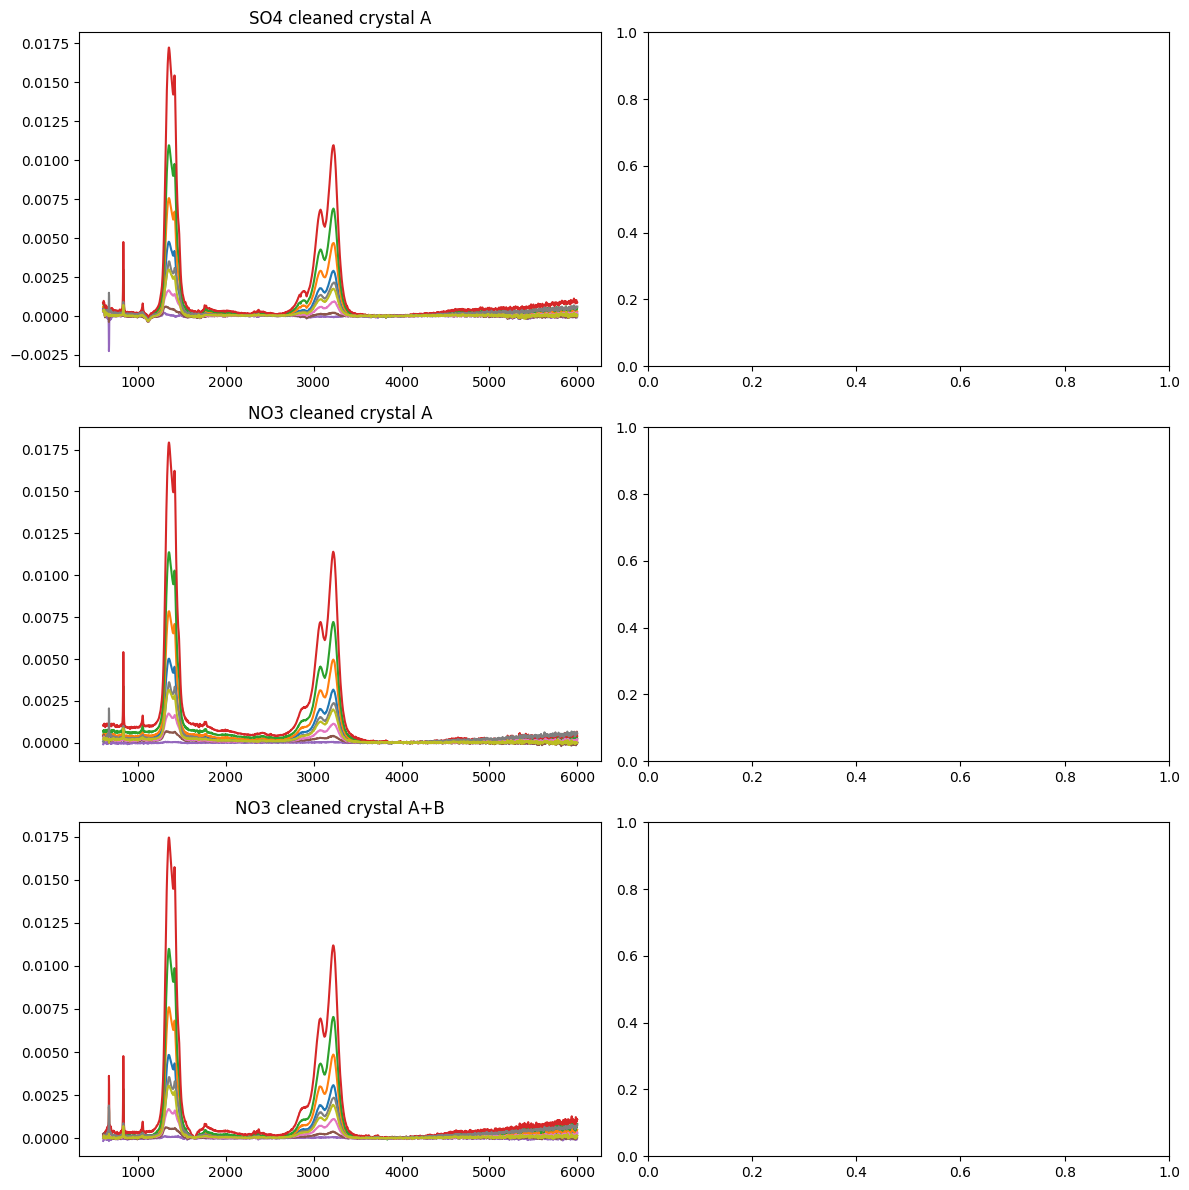

In [82]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns

for i in airmon_NO3["loaded_crystal_A"]["SO4_cleaned_crystal_A"]:
    axs[0, 0].plot(wn, i["absorbance"])
axs[0, 0].set_title("SO4 cleaned crystal A")

# for i in airmon_NO3["loaded_crystal_A"]["SO4_NO3_cleaned_crystal_A"]:
#     axs[0, 1].plot(wn, i["absorbance"])
# axs[0, 1].set_title("SO4 + NO3 cleaned crystal A")
    
for i in airmon_NO3["loaded_crystal_A"]["NO3_cleaned_crystal_A"]:
    axs[1, 0].plot(wn, i["absorbance"])
axs[1, 0].set_title("NO3 cleaned crystal A")
    
# for i in airmon_NO3["loaded_crystal_A"]["cleaned_crystal_Jap"]:
#     axs[1, 1].plot(wn, i["absorbance"])
# axs[1, 1].set_title("Cleaned crystal Japan")

# for i in airmon_NO3["loaded_crystal_A"]["cleaned_crystal_Jap"]:
#     axs[1, 1].plot(wn, i["absorbance"])
# axs[1, 1].set_title("Cleaned crystal Japan")

for i in airmon_NO3["loaded_crystal_A"]["NO3_cleaned_crystal_A+B"]:
    axs[2, 0].plot(wn, i["absorbance"])
axs[2, 0].set_title("NO3 cleaned crystal A+B")

# for i in airmon_NO3["loaded_crystal_A"]["NO3_SO4_cleaned_crystal_A+B"]:
#     axs[2, 1].plot(wn, i["absorbance"])
# axs[2, 1].set_title("NO3 + SO4 cleaned crystal A+B")

plt.tight_layout()
plt.show()

In [137]:
chat_cv = loo_pca(np.array(ZB))[1]
mu, lam, V, W = pca(np.array(ZB))
W = W[:, :chat_cv]

distribute_args = [(np.array(YB.iloc[i]), mu, W, 1e-5, 0.5 + 1e-5, "PB", YB.iloc[i].name) for i in range(len(YB))] 

with mp.Pool(processes=mp.cpu_count()) as pool:
                results = list(
                    tqdm(
                        pool.imap(distribute_veb, distribute_args),
                        total=len(distribute_args),
                    )
                )
                
for i in tqdm(range(len(results))):
    boot_x, boot_a = pca_bootstrap(YB.loc[results[i]["sample_id"]].to_numpy(), np.array(ZB), results[i]["tau"], results[i]["sigma_hat"], chat_cv, B=100, loss="PB", verbose=False)
    
    alpha = 0.01
    stdev = np.std(boot_a, axis=0)
    r = results[i]["absorbance"]- boot_a
    crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
    LOD = crit*stdev
    
    results[i]["alpha"] = alpha
    results[i]["stdev"] = stdev
    results[i]["crit"] = crit
    results[i]["LOD"] = LOD
    
airmon_SO4["crysal_B"] = results

100%|██████████| 13/13 [00:50<00:00,  3.86s/it]


In [140]:
with open("../data/temp/airmon_SO4.pkl", "wb") as f:
    pickle.dump(airmon_SO4, f)

[{'sample_id': '20250603_ammoniumsulfate_calibration_1_A',
  'absorbance': array([-1.52051873e-04, -1.62618114e-04, -6.43402397e-05, ...,
         -1.17386658e-04, -8.49756620e-05,  2.75393799e-06], shape=(2799,)),
  'time': 0.07790184020996094,
  'tau': np.float64(0.28038635439125553),
  'c': 3,
  'sigma_hat': np.float64(1.6860407189807237e-05),
  'nu': array([-0.75711211, -0.96022739,  4.91005578]),
  'd': array([0.0004432 , 0.00750006, 0.01859866]),
  'x': array([-0.75722536, -0.95817752,  4.91490953]),
  'KL_components': array([ 7.50809518,  4.85389005, 15.53916263]),
  'mean_KL': np.float64(9.300382618942487),
  'mean_mdist': np.float64(8.549276710065767),
  'zstats': array([-1708.27908908,  -128.02921079,   264.00052069]),
  'alpha': 0.01,
  'stdev': array([6.72648830e-04, 6.87126311e-04, 7.01975104e-04, ...,
         7.93232327e-05, 8.74932245e-05, 5.68318955e-05], shape=(2799,)),
  'crit': np.float64(4.880138504110581),
  'LOD': array([0.00328262, 0.00335327, 0.00342574, ..., 0

In [29]:
results[0]

{'sample_id': '20250603_ammoniumsulfate_calibration_1_A',
 'absorbance': array([-1.52051873e-04, -1.62618114e-04, -6.43402397e-05, ...,
        -1.17386658e-04, -8.49756620e-05,  2.75393799e-06], shape=(2799,)),
 'time': 0.07790184020996094,
 'tau': np.float64(0.28038635439125553),
 'c': 3,
 'sigma_hat': np.float64(1.6860407189807237e-05),
 'nu': array([-0.75711211, -0.96022739,  4.91005578]),
 'd': array([0.0004432 , 0.00750006, 0.01859866]),
 'x': array([-0.75722536, -0.95817752,  4.91490953]),
 'KL_components': array([ 7.50809518,  4.85389005, 15.53916263]),
 'mean_KL': np.float64(9.300382618942487),
 'mean_mdist': np.float64(8.549276710065767),
 'zstats': array([-1708.27908908,  -128.02921079,   264.00052069])}

In [125]:
i = 10

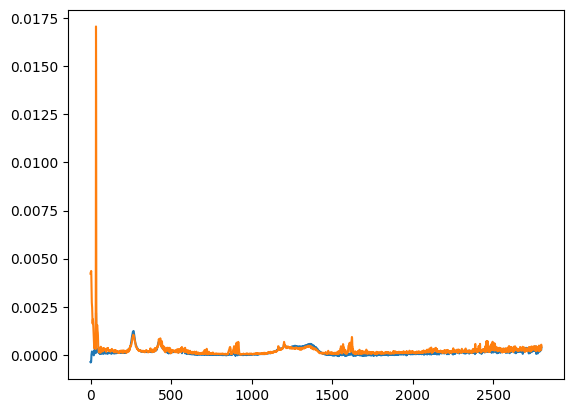

In [128]:
plt.plot(results[i]["absorbance"])
plt.plot(LOD)

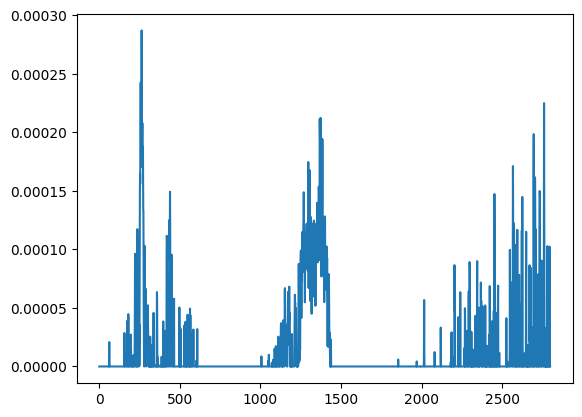

In [129]:
ULOD  = results[i]["absorbance"] - LOD
ULOD[ULOD < 0] = 0
plt.plot(ULOD)


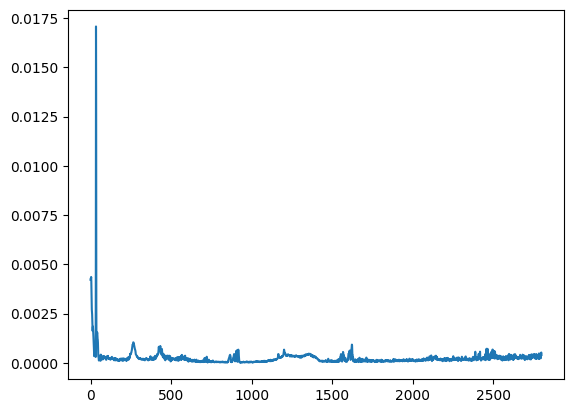

In [131]:
plt.plot(LOD)

In [74]:
crit

np.float64(3.0477598242194492)

array([-1.52051873e-04, -1.62618114e-04, -6.43402397e-05, ...,
       -1.17386658e-04, -8.49756620e-05,  2.75393799e-06], shape=(2799,))

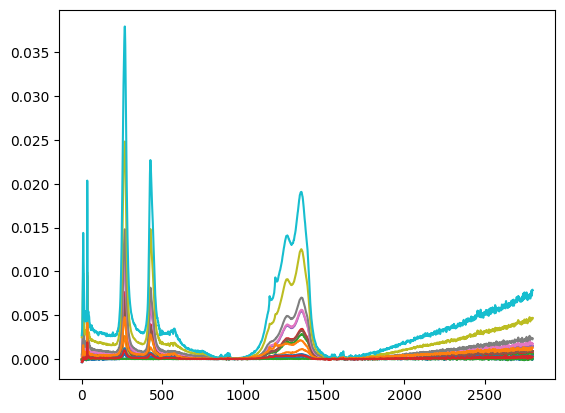

In [26]:
for i in results:
    plt.plot(i["absorbance"])

In [ ]:
l

In [22]:
distribute_veb(distribute_args[0])

{'sample_id': '20250603_ammoniumsulfate_calibration_1_A',
 'absorbance': array([-1.52051873e-04, -1.62618114e-04, -6.43402397e-05, ...,
        -1.17386658e-04, -8.49756620e-05,  2.75393800e-06], shape=(2799,)),
 'time': 0.07128667831420898,
 'tau': np.float64(0.28038635466916983),
 'c': 3,
 'sigma_hat': np.float64(1.6860407199725742e-05),
 'nu': array([-0.75711211, -0.96022739,  4.91005578]),
 'd': array([0.0004432 , 0.00750006, 0.01859866]),
 'x': array([-0.75722536, -0.95817752,  4.91490953]),
 'KL_components': array([ 7.50809523,  4.85389005, 15.53916262]),
 'mean_KL': np.float64(9.300382634562476),
 'mean_mdist': np.float64(8.5492767101044),
 'zstats': array([-1708.27918424,  -128.02921079,   264.0005183 ])}

In [21]:
args[0]

array([1.67380357, 1.66996244, 1.66933847, ..., 1.47131725, 1.47204884,
       1.47273031], shape=(2799,))

In [ ]:
args = 

{'sample_id': '20250603_ammoniumsulfate_calibration_1_A',
 'absorbance': array([-1.52051873e-04, -1.62618114e-04, -6.43402397e-05, ...,
        -1.17386658e-04, -8.49756620e-05,  2.75393800e-06], shape=(2799,)),
 'time': 0.07726430892944336,
 'tau': np.float64(0.28038635466916983),
 'c': 3,
 'sigma_hat': np.float64(1.6860407199725742e-05),
 'nu': array([-0.75711211, -0.96022739,  4.91005578]),
 'd': array([0.0004432 , 0.00750006, 0.01859866]),
 'x': array([-0.75722536, -0.95817752,  4.91490953]),
 'KL_components': array([ 7.50809523,  4.85389005, 15.53916262]),
 'mean_KL': np.float64(9.300382634562476),
 'mean_mdist': np.float64(8.5492767101044),
 'zstats': array([-1708.27918424,  -128.02921079,   264.0005183 ])}

In [ ]:
# chat_cv = loo_pca(np.array(ZA))[1]
# mu, lam, V, W = pca(np.array(ZA))
# W = W[:, :chat_cv]

A = []

for i in range(YA.shape[0]):
    # if YA.iloc[i].name in ZA.index:
    #     idx = np.where(ZA.index != YA.iloc[i].name)[0]
    #     Zl = np.array(ZA)[idx]
    
    # else:
    #     Zl = np.array(ZA)
        
    # Zl = (Zl.T - Zl[:,0]).T
    # Zl = Zl[:,1:]

    Zl = np.array(ZA)
    #Zl = (Zl.T - Zl[:,0]).T
    #Zl = Zl[:,1500:]
    mu, lam, V, W = pca(np.array(Zl))
    W = W[:, :chat_cv]
    mod = VEB(c=chat_cv)

    y = np.array(YA.iloc[i])
    #y = y - y[0]
    #y = y[1500:]
    
    mod.fit(y,mu,W)
    mod.map(y,mu,W)
    A.append(mod.absorbance)
    
dfA = pd.DataFrame(A, index=YA.index, columns=YA)

# chat_cv = loo_pca(np.array(ZB))[1]
# mu, lam, V, W = pca(np.array(ZB))
# W = W[:, :chat_cv]

# A = []
# mod = VEB(c=chat_cv)
# for i in range(YB.shape[0]):
#     mod.fit(np.array(YB.iloc[i]),mu,W)
#     mod.map(np.array(YB.iloc[i]),mu,W)
#     A.append(mod.absorbance)
    
# dfB = pd.DataFrame(A, index=YB.index, columns=YB.columns)
    
# df = pd.concat([df, pd.DataFrame(A, index=YB.index, columns=YB.columns)])

# df.to_csv("../data/temp/df_all_wn.csv")

ValueError: Index data must be 1-dimensional

In [117]:
dfA = pd.DataFrame(A, index=YA.index, columns=YA.columns)

In [115]:
A

[array([-1.25041917e-05, -5.56353586e-05,  6.29137711e-05, ...,
        -1.52207455e-04, -1.20903003e-04, -4.02840976e-06], shape=(2799,)),
 array([ 8.92619312e-14, -1.99806730e-05,  1.18762692e-04, ...,
         2.94252313e-05,  1.84426654e-05,  2.29123183e-04], shape=(2799,)),
 array([ 4.42497374e-05, -1.84892755e-05,  1.48664181e-04, ...,
         2.67900136e-04,  2.58133073e-04,  5.69159469e-04], shape=(2799,)),
 array([ 8.05972179e-05, -1.34114941e-13,  1.97568724e-04, ...,
         6.10109430e-04,  5.91109420e-04,  8.21473908e-04], shape=(2799,)),
 array([9.13362175e-05, 4.34687841e-11, 1.15961989e-04, ...,
        1.20451579e-03, 1.22084825e-03, 1.39804506e-03], shape=(2799,)),
 array([ 1.13154018e-04, -8.80873152e-11,  1.20581891e-04, ...,
         7.00260435e-04,  7.06098642e-04,  8.64759768e-04], shape=(2799,)),
 array([4.68078846e-05, 1.11466392e-12, 1.72773209e-04, ...,
        1.63710379e-03, 1.56790280e-03, 1.70937109e-03], shape=(2799,)),
 array([0.00065116, 0.00071148, 

In [107]:
#df = pd.read_csv("../data/temp/df_all_wn.csv", index_col=0)

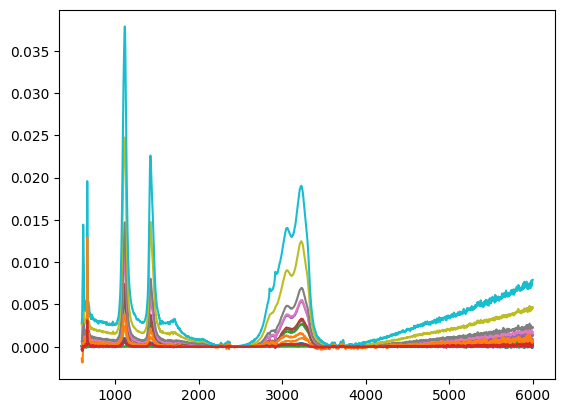

In [118]:
for i in range(dfA.shape[0]):
    plt.plot(dfA.columns,np.array(dfA.iloc[i]))

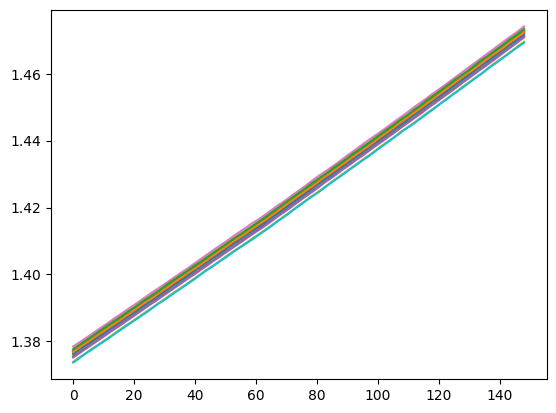

In [112]:
for i in range(Zl.shape[0]):
    plt.plot(np.array(Zl[i][1150:]))

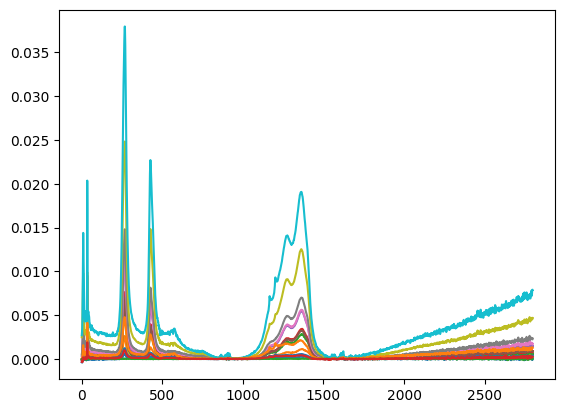

In [72]:
for i in range(dfA.shape[0]):
    plt.plot(np.array(dfA.iloc[i]))

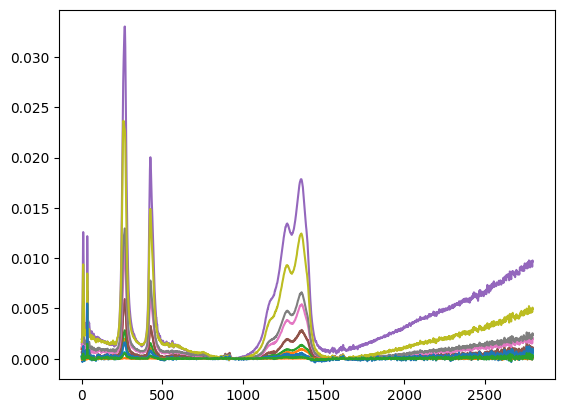

In [73]:
for i in range(dfB.shape[0]):
    plt.plot(np.array(dfB.iloc[i]))

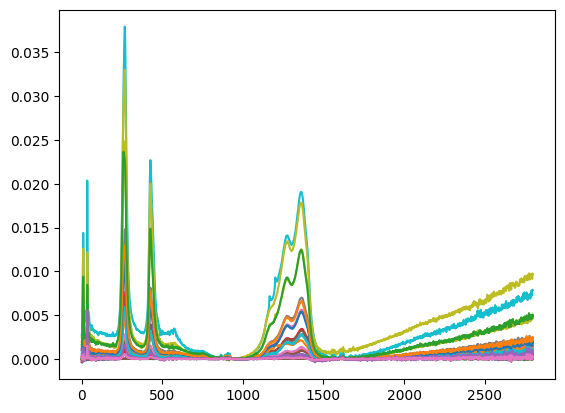

In [53]:
for i in range(df.shape[0]):
    plt.plot(np.array(df.iloc[i]))

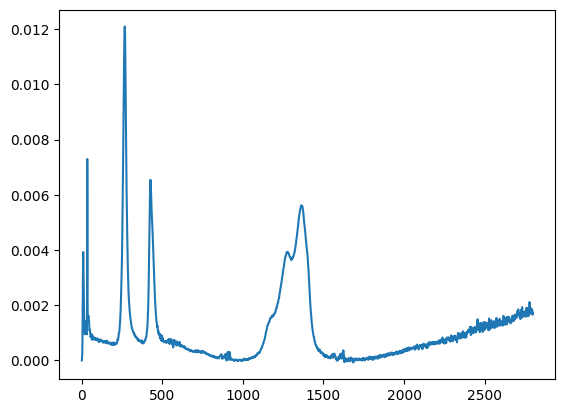

In [61]:
plt.plot(np.array(df.iloc[6]))

In [88]:
wn = np.array(wn)

chat_cv = loo_pca(np.array(ZA)[:,wn < 4000])[1]
mu, lam, V, W = pca(np.array(ZA)[:,wn < 4000])
W = W[:, :chat_cv]

A = []
mod = VEB(c=chat_cv)
for i in range(YA.shape[0]):
    mod.fit(np.array(YA.iloc[i])[wn < 4000],mu,W)
    mod.map(np.array(YA.iloc[i])[wn < 4000],mu,W)
    A.append(mod.absorbance)
    
df = pd.DataFrame(A, index=YA.index, columns=wn[wn < 4000])

chat_cv = loo_pca(np.array(ZB)[:,wn < 4000])[1]
mu, lam, V, W = pca(np.array(ZB)[:,wn < 4000])
W = W[:, :chat_cv]

A = []
mod = VEB(c=chat_cv)
for i in range(YB.shape[0]):
    mod.fit(np.array(YB.iloc[i])[wn < 4000],mu,W)
    mod.map(np.array(YB.iloc[i])[wn < 4000],mu,W)
    A.append(mod.absorbance)
    
df = pd.concat([df, pd.DataFrame(A, index=YB.index, columns=wn[wn < 4000])])

df.to_csv("../data/temp/df_excl_wn.csv")

In [89]:
df = pd.read_csv("../data/temp/df_excl_wn.csv", index_col=0)

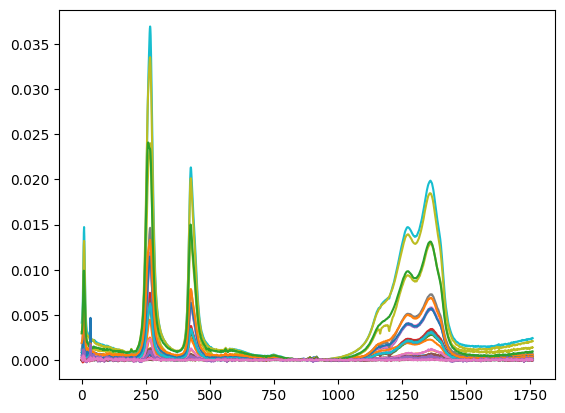

In [90]:
for i in range(df.shape[0]):
    plt.plot(np.array(df.iloc[i]))

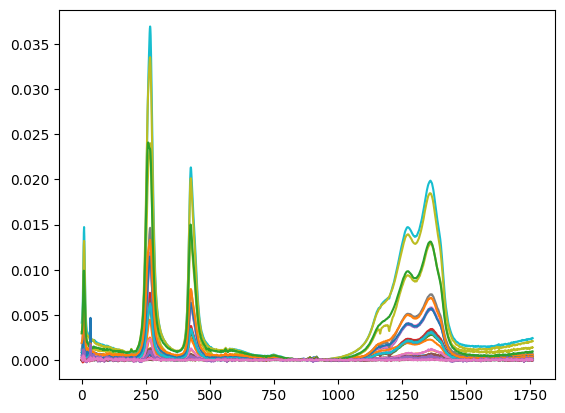

In [98]:
for i in range(df.shape[0]):
    plt.plot(np.array(df.iloc[i]))

In [106]:
wn = np.array(wn)
up_wn = 5000

chat_cv = loo_pca(np.array(ZA)[:,wn < up_wn])[1]
mu, lam, V, W = pca(np.array(ZA)[:,wn < up_wn])
W = W[:, :chat_cv]

A = []
mod = VEB(c=chat_cv)
for i in range(YA.shape[0]):
    mod.fit(np.array(YA.iloc[i])[wn < up_wn],mu,W)
    mod.map(np.array(YA.iloc[i])[wn < up_wn],mu,W)
    A.append(mod.absorbance)
    
df = pd.DataFrame(A, index=YA.index, columns=wn[wn < up_wn])
chat_cv = loo_pca(np.array(ZB)[:,wn < up_wn])[1]
mu, lam, V, W = pca(np.array(ZB)[:,wn < up_wn])
W = W[:, :chat_cv]

A = []
mod = VEB(c=chat_cv)
for i in range(YB.shape[0]):
    mod.fit(np.array(YB.iloc[i])[wn < up_wn],mu,W)
    mod.map(np.array(YB.iloc[i])[wn < up_wn],mu,W)
    A.append(mod.absorbance)
    
df = pd.concat([df, pd.DataFrame(A, index=YB.index, columns=wn[wn < up_wn])])

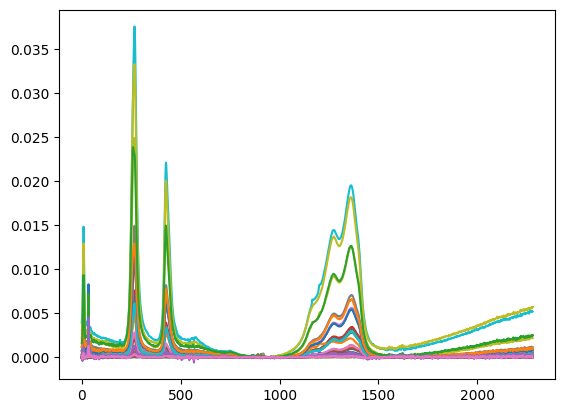

In [107]:
for i in range(df.shape[0]):
    plt.plot(np.array(df.iloc[i]))

In [ ]:
aa

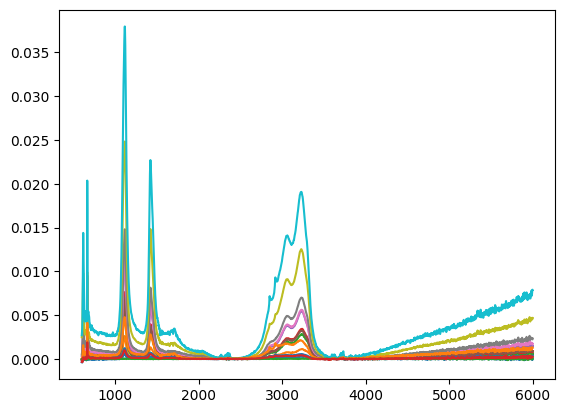

In [73]:
for i in range(len(A)):
    plt.plot(wn, A[i], label=YA.index[i])

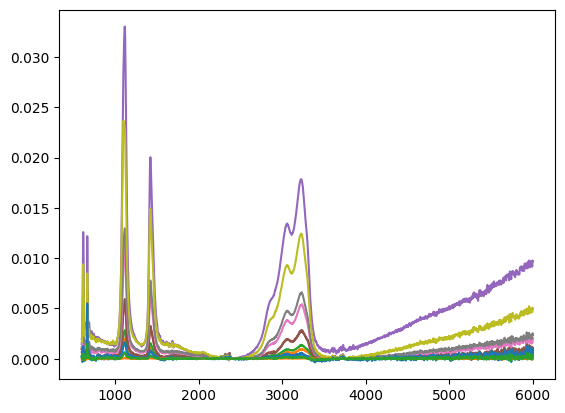

In [76]:
for i in range(len(A)):
    plt.plot(wn, A[i], label=YB.index[i])

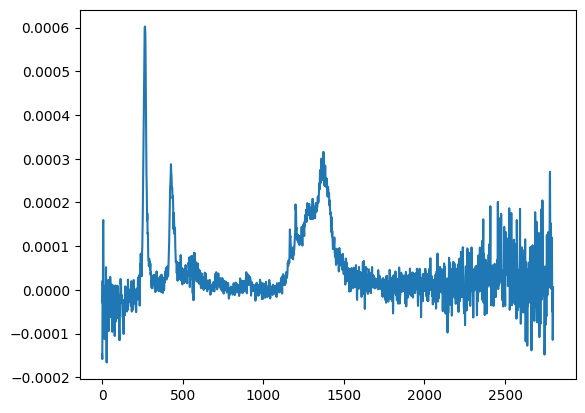

In [55]:
plt.plot(A[0])

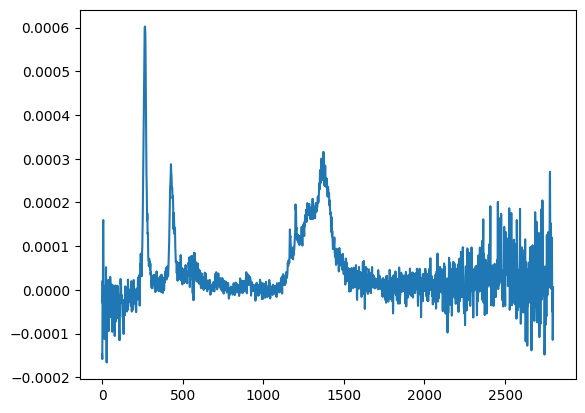

In [42]:
mod = VEB(c=chat_cv)
mod.fit(np.array(YA.iloc[0]),mu,W)
mod.map(np.array(YA.iloc[0]),mu,W)
plt.plot(mod.absorbance)

In [34]:
YA.iloc[3]

601.7     1.673744
603.7     1.669963
605.6     1.669341
607.5     1.670777
609.5     1.672212
            ...   
5990.5    1.470289
5992.4    1.470970
5994.3    1.471622
5996.2    1.472295
5998.2    1.472991
Name: 20250603_ammoniumsulfate_calibration_7_A, Length: 2799, dtype: float64

In [35]:
ZA

,601.7,603.7,605.6,607.5,609.5,611.4,613.3,615.2,617.2,619.1,...,5980.8,5982.7,5984.7,5986.6,5988.5,5990.5,5992.4,5994.3,5996.2,5998.2
20250603_ammoniumsulfate_calibration_10_B,1.669902,1.666075,1.665283,1.666542,1.667878,1.668143,1.667195,1.664418,1.658071,1.647465,...,1.466221,1.466841,1.467504,1.468185,1.468850,1.469492,1.470133,1.470805,1.471461,1.472130
20250603_ammoniumsulfate_calibration_1_A,1.672104,1.668264,1.667516,1.668784,1.670082,1.670363,1.669467,1.666684,1.660313,1.649749,...,1.466580,1.467273,1.467928,1.468618,1.469297,1.469903,1.470523,1.471190,1.471893,1.472583
20250603_ammoniumsulfate_calibration_2_B,1.669687,1.665740,1.664931,1.666254,1.667599,1.667889,1.667006,1.664210,1.657815,1.647230,...,1.466021,1.466694,1.467364,1.468081,1.468802,1.469446,1.470085,1.470735,1.471399,1.472075
20250603_ammoniumsulfate_calibration_4_B,1.671525,1.667701,1.667010,1.668398,1.669716,1.669883,1.668847,1.665891,1.659314,1.648631,...,1.466342,1.467063,1.467715,1.468335,1.468931,1.469584,1.470293,1.470958,1.471665,1.472378
20250603_ammoniumsulfate_calibration_6_B,1.669716,1.665847,1.665138,1.666434,1.667730,1.667957,1.667016,1.664265,1.657902,1.647278,...,1.466196,1.466875,1.467494,1.468115,1.468792,1.469519,1.470225,1.470850,1.471490,1.472180
20250603_ammoniumsulfate_calibration_7_A,1.672420,1.668520,1.667764,1.669134,1.670510,1.670722,1.669711,1.666906,1.660564,1.649972,...,1.466578,1.467279,1.467905,1.468551,1.469233,1.469925,1.470651,1.471385,1.472070,1.472706
20250603_ammoniumsulfate_calibration_8_B,1.669859,1.666026,1.665286,1.666627,1.667951,1.668141,1.667194,1.664410,1.658001,1.647383,...,1.466095,1.466795,1.467464,1.468115,1.468814,1.469492,1.470144,1.470838,1.471513,1.472162
20250603_ammoniumsulfate_calibration_9_A,1.672661,1.668776,1.668005,1.669354,1.670699,1.670871,1.669912,1.667128,1.660762,1.650203,...,1.466786,1.467459,1.468105,1.468797,1.469481,1.470148,1.470842,1.471542,1.472225,1.472907
20250604_ammoniumsulfate_calibration_10_B,1.663605,1.659633,1.658835,1.660244,1.661710,1.662063,1.661261,1.658697,1.652629,1.642316,...,1.462825,1.463495,1.464194,1.464861,1.465482,1.466193,1.466946,1.467605,1.468269,1.468995
20250604_ammoniumsulfate_calibration_11_A,1.668324,1.664401,1.663617,1.664940,1.666316,1.666661,1.665869,1.663241,1.657031,1.646573,...,1.464984,1.465665,1.466383,1.467080,1.467715,1.468306,1.468962,1.469702,1.470445,1.471142


In [ ]:
A = []
for i in tqdm(range(len(Y))):

    spectra_name = Y.iloc[i].name
    try:
        Zloo = np.array(Z.drop(index=spectra_name))
    except KeyError:
        Zloo = np.array(Z)
    Zloo = Zloo[:, wn < 4000]

    chat_cv = loo_pca(Zloo)[1]
    mu, lam, V, W = pca(Zloo)
    W = W[:, :chat_cv]

    mod = VEB(c=chat_cv)
    mod.fit(np.array(Y.iloc[i])[wn < 4000],mu,W)
    mod.map(np.array(Y.iloc[i])[wn < 4000],mu,W)
    A.append(mod.absorbance)

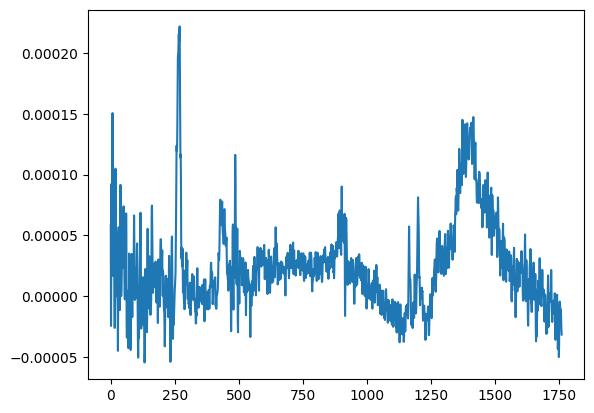

In [409]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()
contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A","20250603_ammoniumsulfate_calibration_5_A","20250605_ammoniumsulfate_calibration5k_3_A"
                      ,"20250603_ammoniumsulfate_calibration_4_B","20250604_ammoniumsulfate_calibration_12_B"]

Z.drop(index=contaminated_names, inplace=True)
Z = np.array(Z)[:, wn < 4000]
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)

W = W[:, :chat_cv]

mod = VEB(c=chat_cv)
mod.fit(np.array(Y.iloc[0][wn < 4000]),mu,W)
mod.map(np.array(Y.iloc[0][wn < 4000]),mu,W)
plt.plot(mod.absorbance)

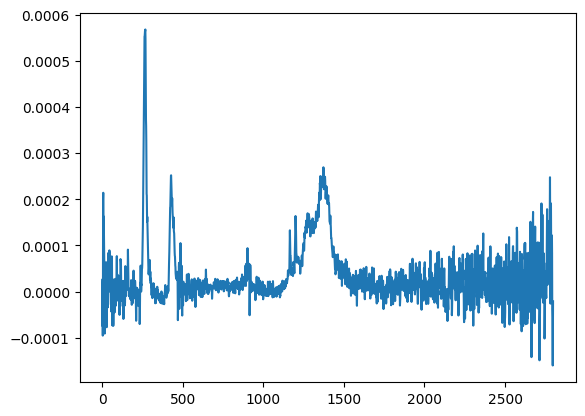

In [ ]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()

contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_4_B",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

Z.drop(index=contaminated_names, inplace=True)




In [27]:
A = []
for i in tqdm(range(len(Y))):

    spectra_name = Y.iloc[i].name
    try:
        Zloo = np.array(Z.drop(index=spectra_name))
    except KeyError:
        Zloo = np.array(Z)
    Zloo = Zloo[:, wn < 4000]

    chat_cv = loo_pca(Zloo)[1]
    mu, lam, V, W = pca(Zloo)
    W = W[:, :chat_cv]

    mod = VEB(c=chat_cv)
    mod.fit(np.array(Y.iloc[i])[wn < 4000],mu,W)
    mod.map(np.array(Y.iloc[i])[wn < 4000],mu,W)
    A.append(mod.absorbance)

100%|██████████| 27/27 [00:12<00:00,  2.21it/s]


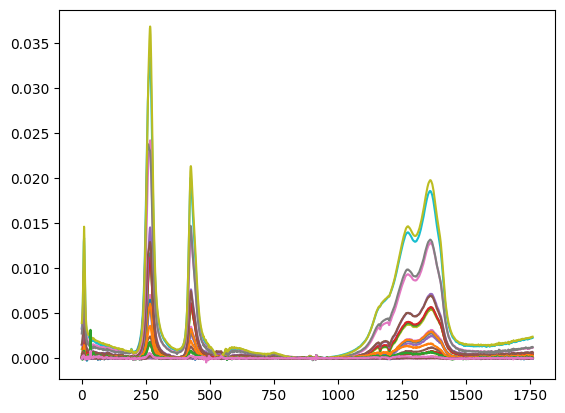

In [28]:
for i in range(len(A)):
    plt.plot(A[i])

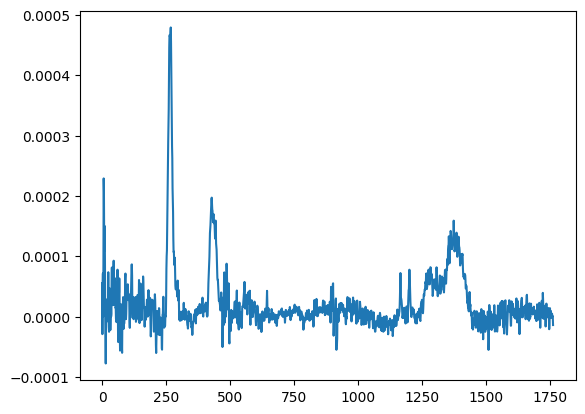

In [461]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()
Z = pd.concat([Z, cleaned_spectra_dict["japan"]])
contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_4_B",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

Z.drop(index=contaminated_names, inplace=True)
Z = np.array(Z)
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)

W = W[:, :chat_cv]

mod = VEB(c=chat_cv)
mod.fit(np.array(Y.iloc[0]),mu,W,tau_max=0.5 + 1e-5)
mod.map(np.array(Y.iloc[0]),mu,W)
plt.plot(mod.absorbance[wn < 4000])

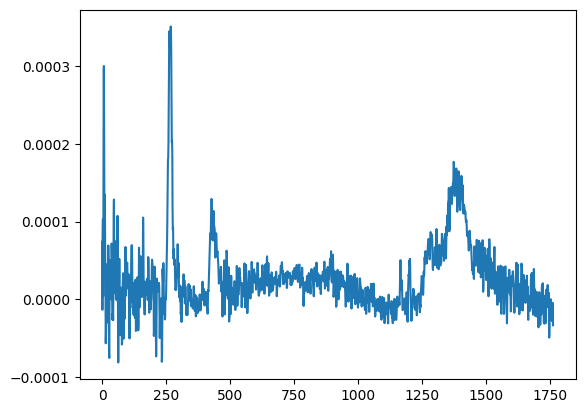

In [414]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()
contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_4_B",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

Z.drop(index=contaminated_names, inplace=True)
Z = np.array(Z)[:, wn < 4000]
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)

W = W[:, :chat_cv]

mod = VEB(c=chat_cv)
mod.fit(np.array(Y.iloc[0][wn < 4000]),mu,W)
mod.map(np.array(Y.iloc[0][wn < 4000]),mu,W)
plt.plot(mod.absorbance)

In [472]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()
Z = pd.concat([Z, cleaned_spectra_dict["japan"]])
Z = pd.concat([Z, cleaned_spectra_dict["ammonium_nitrate_calibration"]])

contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_4_B",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

Z.drop(index=contaminated_names, inplace=True)
Z = np.array(Z)
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)

W = W[:, :chat_cv]

In [473]:
chat_cv 

np.int64(32)

In [474]:
mod = VEB(chat_cv)
taus = []
sigmas = []
A = []
for i in tqdm(range(Y.shape[0])):
    mod.fit(np.array(Y.iloc[i]),mu,W,tau_max=0.5 + 1e-5)
    mod.map(np.array(Y.iloc[i]),mu,W)
    taus.append(mod.tau)
    sigmas.append(mod.sigma_hat)
    A.append(mod.absorbance)

100%|██████████| 27/27 [01:44<00:00,  3.88s/it]


In [ ]:
df_all_wn = pd.DataFrame(A)
df_all_wn.columns = wn
df_all_wn.index = Y.index
df_all_wn.to_csv("../data/temp/df_all_wn.csv")

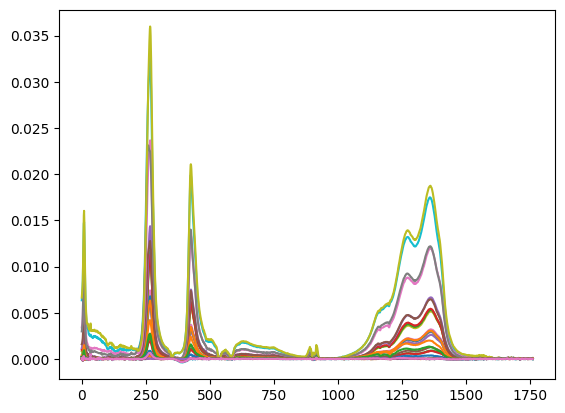

In [476]:
for i in range(len(A)):
    plt.plot(A[i][wn < 4000])

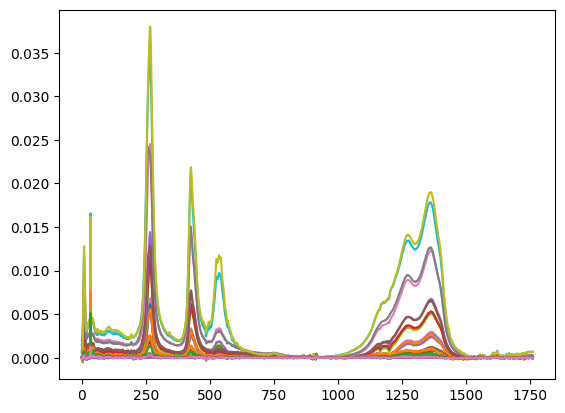

In [448]:
for i in range(len(A)):
    plt.plot(A[i][wn < 4000])

In [466]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"].copy()
Z = pd.concat([Z, cleaned_spectra_dict["japan"]])
contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_4_B",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

Z.drop(index=contaminated_names, inplace=True)
Z = np.array(Z)[:, wn < 4000]
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)

W = W[:, :chat_cv]

In [467]:
mod = VEB(chat_cv)
taus = []
sigmas = []
A = []
for i in tqdm(range(Y.shape[0])):
    mod.fit(np.array(Y.iloc[i])[wn < 4000],mu,W,tau_max=0.5 + 1e-5)
    mod.map(np.array(Y.iloc[i])[wn < 4000],mu,W)
    taus.append(mod.tau)
    sigmas.append(mod.sigma_hat)
    A.append(mod.absorbance)

100%|██████████| 27/27 [01:02<00:00,  2.30s/it]


In [451]:
df_excl_wn = pd.DataFrame(A)
df_excl_wn.columns = wn[wn < 4000]
df_excl_wn.index = Y.index
df_excl_wn.to_csv("../data/temp/df_excl_wn.csv")

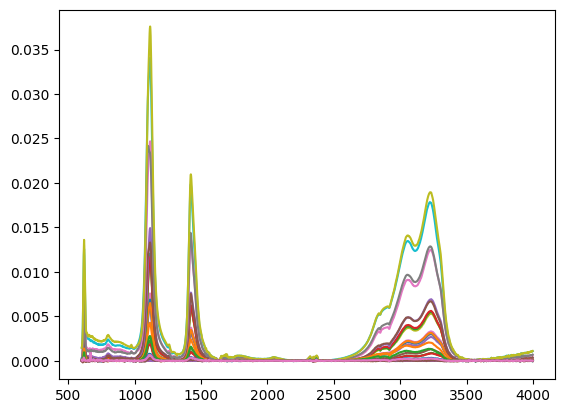

In [468]:
for i in range(len(A)):
    plt.plot(wn[wn < 4000], A[i])

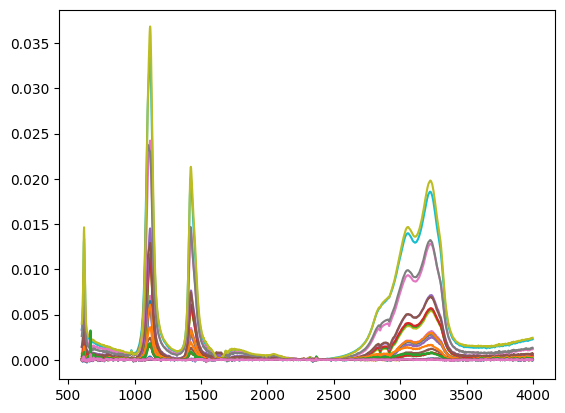

In [454]:
for i in range(len(A)):
    plt.plot(wn[wn < 4000], A[i])

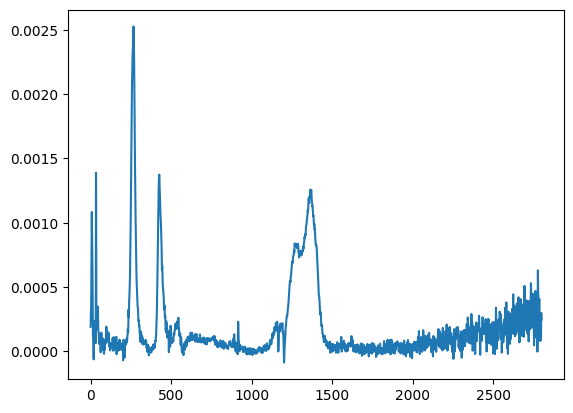

In [427]:
plt.plot(A[5])

In [ ]:
mod = VEB(c=chat_cv)
mod.fit(np.array(Y.iloc[0]),mu,W)
mod.map(np.array(Y.iloc[0]),mu,W)
plt.plot(mod.absorbance)

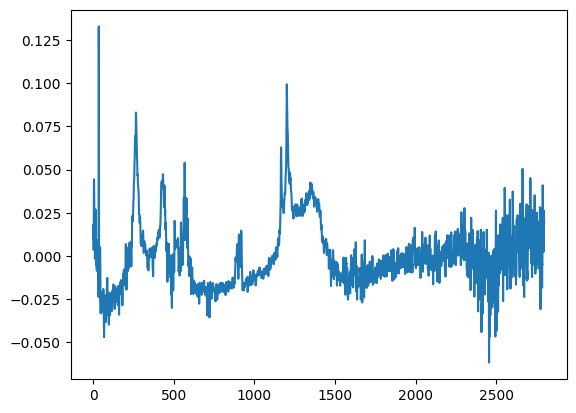

In [389]:
plt.plot(V[:,5])

In [361]:
W.shape

(2799, 29)

In [371]:
chat_cv

np.int64(8)

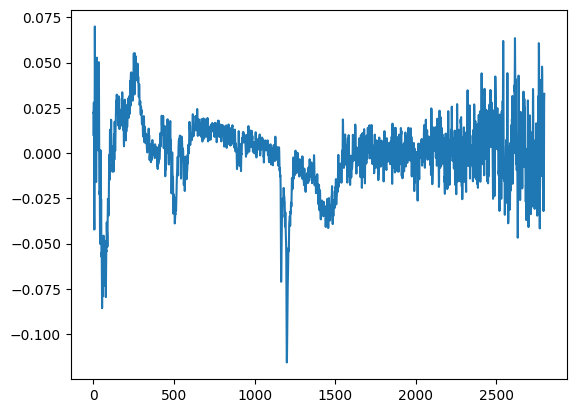

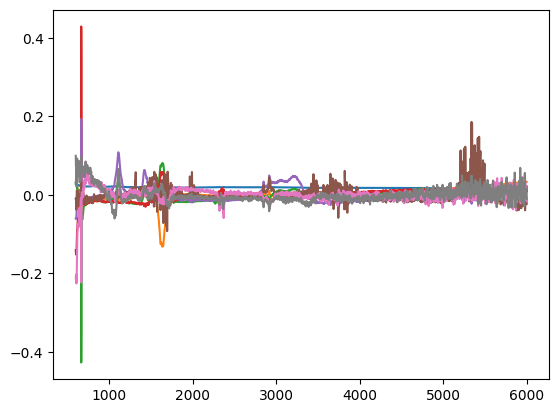

In [364]:
for i in range(chat_cv):
    plt.plot(wn, V[:, i])

In [340]:
# for key in cleaned_spectra_dict.keys():
#     print(key)
#     cleaned_spectra_dict[key]

In [ ]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"]
contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A","20250603_ammoniumsulfate_calibration_5_A","20250605_ammoniumsulfate_calibration5k_3_A"
                      ,"20250603_ammoniumsulfate_calibration_4_B","20250604_ammoniumsulfate_calibration_12_B"]

contaminated_names = ["20250603_ammoniumsulfate_calibration_3_A",
       "20250603_ammoniumsulfate_calibration_4_B",
       "20250603_ammoniumsulfate_calibration_5_A",
       "20250604_ammoniumsulfate_calibration_10_B",
       "20250604_ammoniumsulfate_calibration_12_B",
       "20250605_ammoniumsulfate_calibration5k_3_A",
       "20250605_ammoniumsulfate_calibration5k_smallertime_5_A"]

wn = np.array(Z.columns)


Z.drop(index=contaminated_names, inplace=True)
Z = np.array(Z)
Z =Z[:,wn < 4000]

chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
proj =(Z - mu)@V

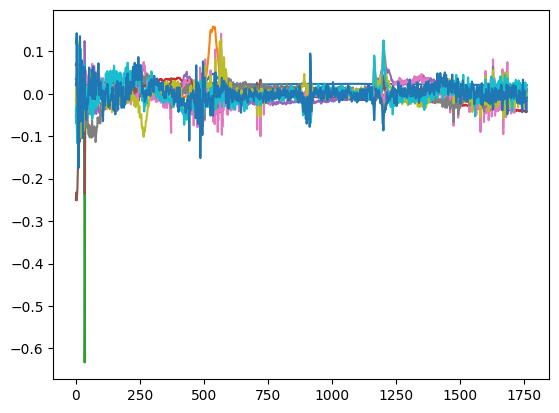

In [342]:
for j in range(chat_cv):
    plt.plot(V[:,j])
   

In [344]:
Y = np.array(loaded_spectra_dict["ammonium_sulphate_calibration"])
Y =Y[:,wn < 4000]
W = W[:, :chat_cv]

In [345]:
mod = VEB(chat_cv)
taus = []
sigmas = []
A = []
for i in tqdm(range(Y.shape[0])):
    mod.fit(Y[i,:],mu,W,tau_max=0.5 + 1e-5)
    mod.map(Y[i,:],mu,W)
    taus.append(mod.tau)
    sigmas.append(mod.sigma_hat)
    A.append(mod.absorbance)

100%|██████████| 27/27 [00:09<00:00,  2.84it/s]


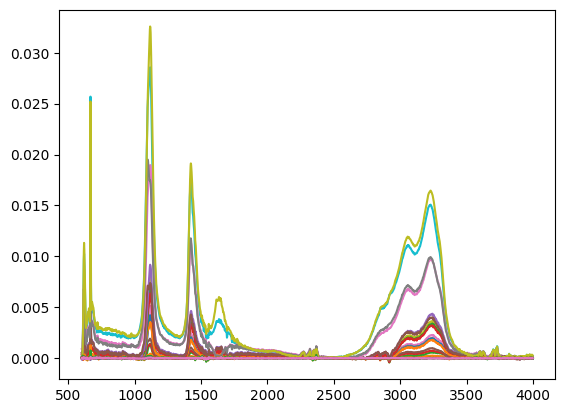

In [337]:
for i in range(len(A)):
    plt.plot(wn[wn < 4000],A[i][wn < 4000])

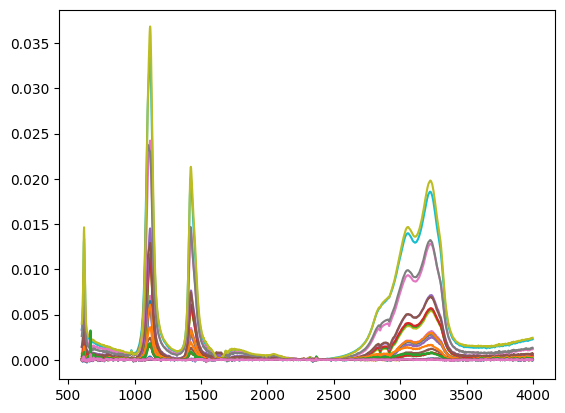

In [346]:
for i in range(len(A)):
    plt.plot(wn[wn < 4000],A[i])

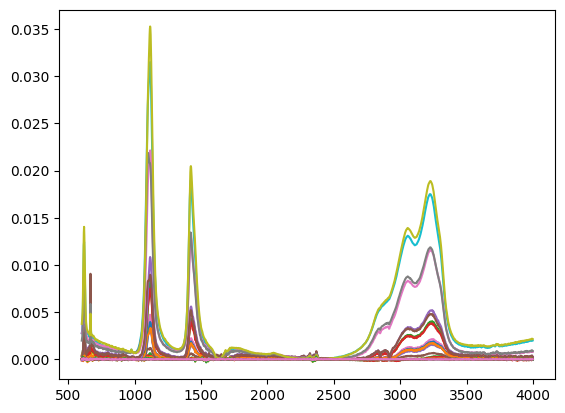

In [329]:
for i in range(len(A)):
    plt.plot(wn[wn < 4000],A[i])

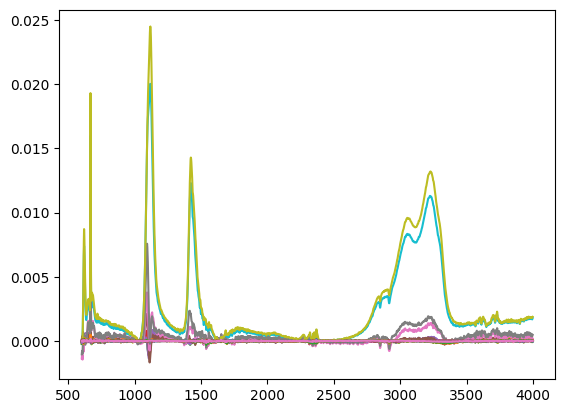

In [323]:
for i in range(len(A)):
    plt.plot(wn[wn < 4000],A[i])

In [347]:
A = np.array(A)

In [348]:
U,D,Vt = svd(A,full_matrices=False)

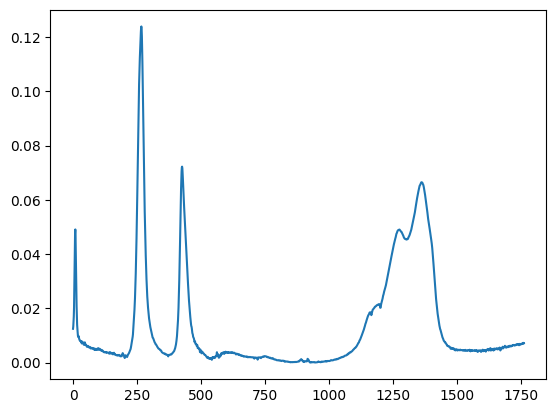

In [352]:
plt.plot(-Vt[0,:])

(array([9., 5., 1., 0., 0., 0., 0., 0., 4., 8.]),
 array([0.00152677, 0.05137509, 0.10122342, 0.15107174, 0.20092006,
        0.25076839, 0.30061671, 0.35046503, 0.40031335, 0.45016168,
        0.50001   ]),
 <BarContainer object of 10 artists>)

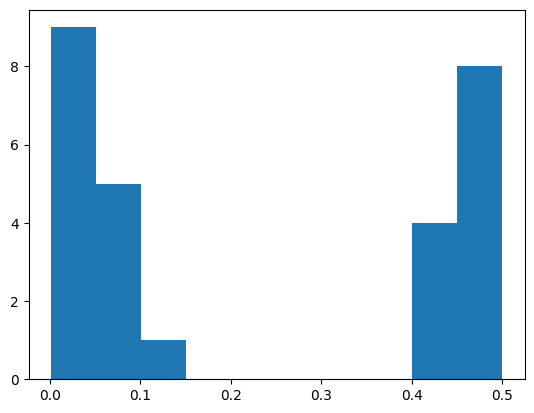

In [293]:
plt.hist(taus)

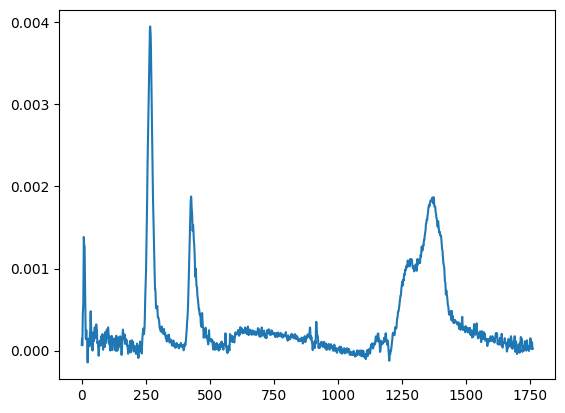

In [288]:
plt.plot(A[10])

In [112]:
So4_comp = (U[:,idx] * lam[idx] ) @ V[:,idx].T

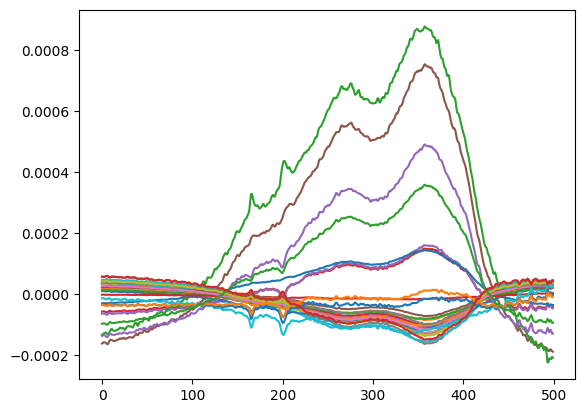

In [120]:
for i in range(So4_comp.shape[0]):
    plt.plot(So4_comp[i,1000:1500])

In [123]:
np.argsort(np.max(So4_comp[:,1000:1500],axis=1))

array([23, 30, 31, 22, 11, 25, 21, 14, 13, 26, 20,  6,  0,  8, 29, 27, 15,
        2, 16, 18, 19, 28,  1,  7,  9, 33, 17, 10,  3,  4, 32, 24,  5, 12])

In [125]:
idx = [3,4,5,10,12,24,32]

In [127]:
mu, lam, V, W = pca(np.delete(Z, idx, axis=0))


In [240]:
Z = np.delete(Z, idx, axis=0)

In [241]:
chat_cv = loo_pca(Z)[1]
mu, lam, V, W = pca(Z)
V = V[:, :chat_cv]
W = W[:, :chat_cv]

In [280]:
W.shape

(1762, 29)

In [243]:
chat_cv

np.int64(9)

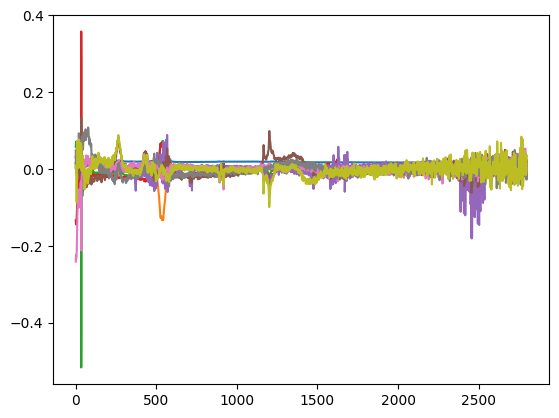

In [137]:
for i in range(V.shape[1]):
    plt.plot(V[:,i])

In [193]:
"20250603_ammoniumsulfate_calibration_1_A"
cleaned_spectra_dict["ammonium_sulphate_calibration"].index[idx]

Index(['20250603_ammoniumsulfate_calibration_3_A',
       '20250603_ammoniumsulfate_calibration_4_B',
       '20250603_ammoniumsulfate_calibration_5_A',
       '20250604_ammoniumsulfate_calibration_10_B',
       '20250604_ammoniumsulfate_calibration_12_B',
       '20250605_ammoniumsulfate_calibration5k_3_A',
       '20250605_ammoniumsulfate_calibration5k_smallertime_5_A'],
      dtype='object')

In [ ]:
  ## "20250603_ammoniumsulfate_calibration_3_A" x
  ## "20250603_ammoniumsulfate_calibration_5_A" x
  ## "20250605_ammoniumsulfate_calibration5k_3_A" 
  ## "20250603_ammoniumsulfate_calibration_4_B"
  ## "20250604_ammoniumsulfate_calibration_12_B"

  ## "ammonium_nitrate_calibration_5_A"
  ## "ammonium_nitrate_calibration_7_A"
  ## "ammonium_nitrate_calibration_6_B" 


In [174]:
idx

[3, 4, 5, 10, 12, 24, 32]

In [250]:
mod = VEB(c=chat_cv)

In [252]:
W = W[:, :chat_cv]

In [261]:
wn = Y.columns

100%|██████████| 27/27 [00:09<00:00,  2.79it/s]


In [254]:
taus = np.array(taus)
sigmas = np.array(sigmas)
A = np.array(A)

{'whiskers': [<matplotlib.lines.Line2D at 0x218f2760ef0>,
 'caps': [<matplotlib.lines.Line2D at 0x218f2761550>,
 'boxes': [<matplotlib.lines.Line2D at 0x218f73400e0>],
 'medians': [<matplotlib.lines.Line2D at 0x218f2760830>],
 'fliers': [<matplotlib.lines.Line2D at 0x218f2762000>],
 'means': []}

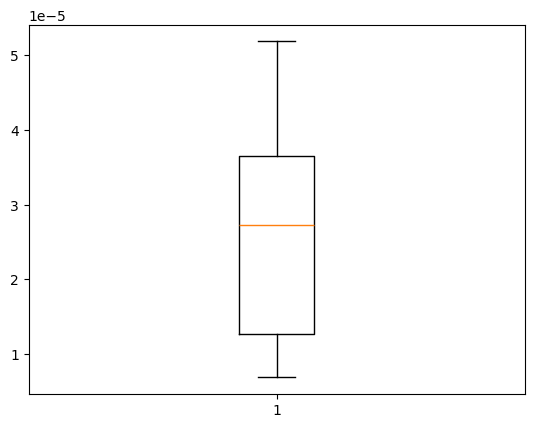

In [255]:
plt.boxplot(sigmas)

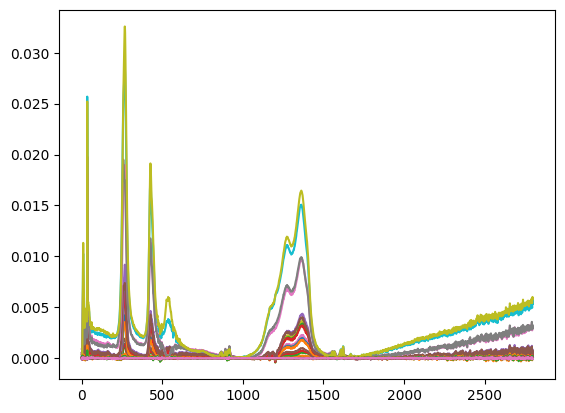

In [256]:
for i in range(A.shape[0]):
    plt.plot(A[i,:])

In [257]:
Z = cleaned_spectra_dict["ammonium_sulphate_calibration"]

In [258]:
Y = loaded_spectra_dict["ammonium_sulphate_calibration"]

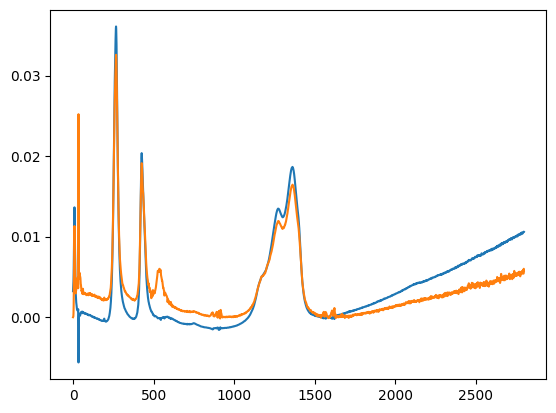

In [259]:
j = 18
spec_name = loaded_spectra_dict["ammonium_sulphate_calibration"].index[j]
y = loaded_spectra_dict["ammonium_sulphate_calibration"].loc[spec_name]
z = cleaned_spectra_dict["ammonium_sulphate_calibration"].loc[spec_name]
plt.plot(np.array(y-z))
plt.plot(A[j])

In [239]:
spec_name

'20250604_ammoniumsulfate_calibration_9_A'

In [222]:
y.shape


(2799,)

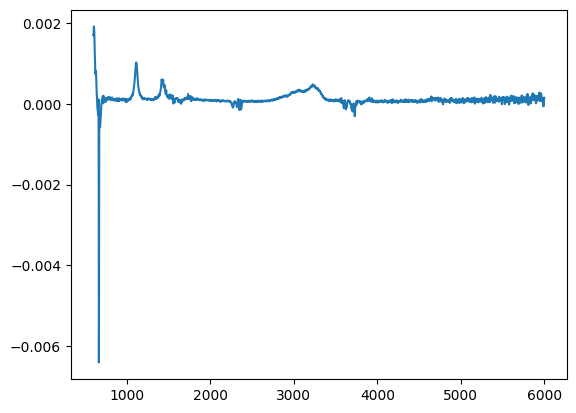